In [91]:
# Cell 1A: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_Hurdle" / "figures_Hurdle_AR1_GRW_P"
RESULTS = PROJ_ROOT / "results" / "results_Hurdle" / "results_Hurdle_AR1_GRW_P"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)


MODEL_NAME = "Hurdle-AR(1)-GRW-P"
MODEL_TAG = "hurdle_ar1_grw_p"


In [92]:
# Cell 1B: analysis settings

EPS = 0.49
N = 1000
Y = 20
SEED = 63

MIN_PROB = 1e-6
MAX_PROB = 1 - 1e-6
MIN_POS_Q = 1e-12

rng = np.random.default_rng(SEED)

stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]


In [93]:
# Cell 1C: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()


(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [94]:
# Cell 4: build empirical panel

df_original['dblp_id'] = df_original['dblp'] + df_original['phd_year'].astype(str)
working_df = (df_original.sort_values(["dblp_id", "CareerAge"]).copy())

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)
working_df["is_active"] = (working_df["pubs_adj"] > 0).astype(int)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)
working_df["is_active_next"] = working_df.groupby("dblp_id")["is_active"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (working_df[is_next_year & is_in_window].dropna(subset=["pubs_adj", "pubs_adj_next", "is_active", "is_active_next"]).copy())

print("Rows in orig:", len(working_df))
print("Rows w/ ok 1yr trans:", len(working_df_fit))
print()
print(working_df_fit[["pubs_adj", "pubs_adj_next", "log_pubs_adj", "log_pubs_next", "log_delta"]].describe())


Rows in orig: 54948
Rows w/ ok 1yr trans: 34701

           pubs_adj  pubs_adj_next  log_pubs_adj  log_pubs_next     log_delta
count  34701.000000   34701.000000  34701.000000   34701.000000  34701.000000
mean       6.426378       6.446431      1.442084       1.448262      0.006178
std        6.475154       6.499782      1.131298       1.123265      1.057639
min        0.000000       0.000000     -0.713350      -0.713350     -5.028100
25%        2.031715       2.031715      0.924939       0.924939     -0.509761
50%        4.775004       4.775004      1.661082       1.661082     -0.026502
75%        9.012406       9.012406      2.251545       2.251545      0.523108
max       80.686837      80.686837      4.396630       4.396630      4.138016


In [95]:
# Cell 3: career stages

stage_order = ["0-4", "5-7", "8-13", "14-20"]

def assign_career_stage(year):
    if 0 <= year <= 4:
        return "0-4"
    elif 5 <= year <= 7:
        return "5-7"
    elif 8 <= year <= 13:
        return "8-13"
    elif 14 <= year <= 20:
        return "14-20"
    else:
        return np.nan

working_df["career_stage"] = working_df["CareerAge"].apply(assign_career_stage)
working_df_fit["career_stage"] = working_df_fit["CareerAge"].apply(assign_career_stage)

print("Prod obs by stage:")
print(working_df["career_stage"].value_counts().reindex(stage_order))
print()
print("Trans obs by starting-year stage:")
print(working_df_fit["career_stage"].value_counts().reindex(stage_order))


Prod obs by stage:
career_stage
0-4      10961
5-7       6647
8-13     11114
14-20     8404
Name: count, dtype: int64

Trans obs by starting-year stage:
career_stage
0-4      10918
5-7       6401
8-13     10496
14-20     6886
Name: count, dtype: int64


In [96]:
# Cell 4: build binary states and transition data

id_col = "dblp_id"
age_col = "CareerAge"
prod_col = "pubs_adj"

state_labels = {
    0: "No pubs",
    1: "Some pubs",}

state_order = [0, 1]
n_states = len(state_order)

df = working_df[working_df[age_col].between(0, Y)].copy()
df["state"] = (df[prod_col] > 0).astype(int)

trans = working_df_fit.copy()
trans["state"] = trans["is_active"].astype(int)
trans["next_state"] = trans["is_active_next"].astype(int)

print(df[[id_col, age_col, prod_col, "state"]].head())
print()
print("State counts:")
print(df["state"].map(state_labels).value_counts())
print()
print("Transition counts by type:")
print(pd.crosstab(trans["state"], trans["next_state"]).rename(index=state_labels, columns=state_labels))


                        dblp_id  CareerAge   pubs_adj  state
3  =Ccedil=etintemel:Ugur2001.0          0   5.209137      1
4  =Ccedil=etintemel:Ugur2001.0          1   6.691238      1
5  =Ccedil=etintemel:Ugur2001.0          2  12.901876      1
6  =Ccedil=etintemel:Ugur2001.0          3   4.667694      1
7  =Ccedil=etintemel:Ugur2001.0          4  12.016541      1

State counts:
state
Some pubs    31549
No pubs       5577
Name: count, dtype: int64

Transition counts by type:
next_state  No pubs  Some pubs
state                         
No pubs        2318       3061
Some pubs      2823      26499


In [97]:
# Cell 5A: yearwise binary transition matrices

def transition_counts_and_probs(g):
    counts = pd.crosstab(g["state"], g["next_state"])
    counts = counts.reindex(index=state_order, columns=state_order, fill_value=0)
    probs = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0)
    return counts, probs

global_counts, global_P = transition_counts_and_probs(trans)

year_counts = {}
year_P = {}

year_transition_rows = []

for year in range(Y):
    g = trans[trans[age_col] == year]
    counts, probs = transition_counts_and_probs(g)

    probs = probs.combine_first(global_P)

    year_counts[year] = counts
    year_P[year] = probs

    year_transition_rows.append({
        "year": year,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

year_transition_summary = pd.DataFrame(year_transition_rows)

print("Global transition probabilities:")
print(global_P.rename(index=state_labels, columns=state_labels).round(3))
print()
print("Yearwise transition summary:")
display(year_transition_summary.round(3))


Global transition probabilities:
next_state  No pubs  Some pubs
state                         
No pubs       0.431      0.569
Some pubs     0.096      0.904

Yearwise transition summary:


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


In [98]:
# Cell 5B: stagewise binary transition summary

stage_counts = {}
stage_P = {}
stage_transition_rows = []

for stage in stage_order:
    g = trans[trans["career_stage"] == stage]
    counts, probs = transition_counts_and_probs(g)
    probs = probs.combine_first(global_P)

    stage_counts[stage] = counts
    stage_P[stage] = probs

    stage_transition_rows.append({
        "stage": stage,
        "n": int(counts.values.sum()),
        "P_nothing_to_nothing": probs.loc[0, 0],
        "P_nothing_to_something": probs.loc[0, 1],
        "P_something_to_nothing": probs.loc[1, 0],
        "P_something_to_something": probs.loc[1, 1],})

stage_transition_summary = pd.DataFrame(stage_transition_rows)

display(stage_transition_summary.round(3))


,stage,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0-4,10918,0.365,0.635,0.099,0.901
1,5-7,6401,0.419,0.581,0.083,0.917
2,8-13,10496,0.463,0.537,0.094,0.906
3,14-20,6886,0.485,0.515,0.109,0.891


logistic dropout model
cnvg: True
NLL: 8604.202
fit gamma on log(1 + Q_t): 1.1886



,year,n_active_transitions,observed_dropout_rate,restart_prob_if_zero,dropout_intercept,dropout_gamma_log1p_q,pred_drop_q25,pred_drop_q50,pred_drop_q75,pred_drop_q95
0,0,1633,0.1641,0.6198,0.2482,1.1886,0.1876,0.1156,0.0688,0.0338
1,1,1710,0.1088,0.6836,-0.2217,1.1886,0.1261,0.0755,0.0441,0.0214
2,2,1879,0.0750,0.6378,-0.4681,1.1886,0.1014,0.0600,0.0348,0.0168
3,3,1989,0.0825,0.6202,-0.2655,1.1886,0.1214,0.0725,0.0423,0.0205
4,4,1997,0.0756,0.5916,-0.2912,1.1886,0.1187,0.0708,0.0413,0.0200
5,5,1942,0.0772,0.5581,-0.2168,1.1886,0.1267,0.0758,0.0443,0.0215
6,6,1880,0.0782,0.5916,-0.2556,1.1886,0.1224,0.0732,0.0427,0.0207
7,7,1806,0.0952,0.5929,-0.0814,1.1886,0.1424,0.0859,0.0504,0.0245
8,8,1710,0.0860,0.5927,-0.2522,1.1886,0.1228,0.0734,0.0429,0.0208
9,9,1636,0.0935,0.5174,-0.1788,1.1886,0.1309,0.0786,0.0460,0.0223


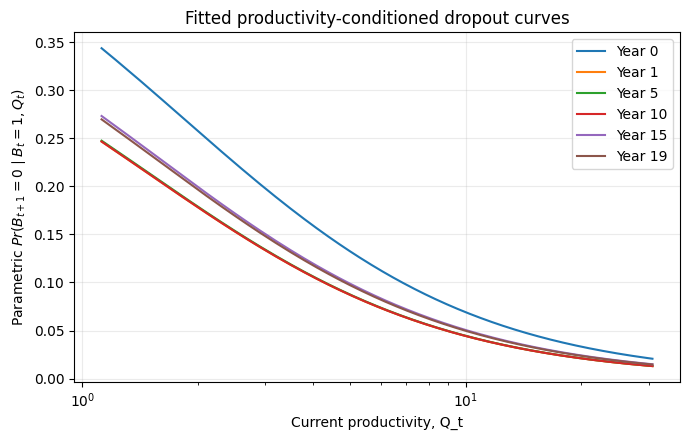

In [99]:
# Cell 6A: fit param prod-conditioned dropout model

active_dropout_fit = trans.loc[(trans["state"] == 1) & trans["pubs_adj"].notna() & trans["next_state"].notna() & trans["CareerAge"].between(0, Y - 1),["CareerAge", "pubs_adj", "next_state"]].copy()

active_dropout_fit["drops_to_zero"] = (active_dropout_fit["next_state"] == 0).astype(int)
active_dropout_fit["log1p_q"] = np.log1p(active_dropout_fit["pubs_adj"].clip(lower=0))

year_idx = active_dropout_fit["CareerAge"].astype(int).to_numpy()
x_log1p_q = active_dropout_fit["log1p_q"].to_numpy(dtype=float)
y_drop = active_dropout_fit["drops_to_zero"].to_numpy(dtype=float)

def sigmoid_stable(x):
    x = np.clip(np.asarray(x, dtype=float), -35, 35)
    return 1 / (1 + np.exp(-x))

def logit_clipped(p):
    p = np.clip(p, MIN_PROB, MAX_PROB)
    return np.log(p / (1 - p))

initial_intercepts = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    raw_rate = g["drops_to_zero"].mean() if len(g) > 0 else y_drop.mean()
    initial_intercepts.append(logit_clipped(raw_rate))

initial_intercepts = np.asarray(initial_intercepts, dtype=float)
initial_log_gamma = np.log(0.25)
initial_theta = np.r_[initial_intercepts, initial_log_gamma]

def dropout_neg_log_likelihood(theta):
    intercepts = theta[:Y]
    gamma = np.exp(theta[Y])

    eta = intercepts[year_idx] - gamma * x_log1p_q
    p_drop = sigmoid_stable(eta)

    nll = -np.sum(y_drop * np.log(np.clip(p_drop, MIN_PROB, MAX_PROB)) +(1 - y_drop) * np.log(np.clip(1 - p_drop, MIN_PROB, MAX_PROB)))
    return nll

bounds = [(-10, 10)] * Y + [(np.log(1e-6), np.log(25.0))]
opt = minimize(dropout_neg_log_likelihood,initial_theta,method="L-BFGS-B",bounds=bounds,)

if not opt.success:
    print("WARNING: bad converge")
    print(opt.message)

fitted_intercepts = opt.x[:Y]
fitted_gamma = float(np.exp(opt.x[Y]))

def predict_dropout_prob(q, year):
    q = np.asarray(q, dtype=float)
    year_arr = np.asarray(year, dtype=int)
    eta = fitted_intercepts[year_arr] - fitted_gamma * np.log1p(np.clip(q, 0, None))
    return np.clip(sigmoid_stable(eta), MIN_PROB, MAX_PROB)

restart_prob_by_year = np.array([np.clip(year_P[year].loc[0, 1], MIN_PROB, MAX_PROB) for year in range(Y)])

q_ref = active_dropout_fit["pubs_adj"].quantile([0.25, 0.50, 0.75, 0.95]).to_dict()

dropout_param_rows = []
for year in range(Y):
    g = active_dropout_fit.loc[active_dropout_fit["CareerAge"] == year]
    observed_dropout_rate = g["drops_to_zero"].mean() if len(g) > 0 else np.nan
    dropout_param_rows.append({
        "year": year,
        "n_active_transitions": len(g),
        "observed_dropout_rate": observed_dropout_rate,
        "restart_prob_if_zero": restart_prob_by_year[year],
        "dropout_intercept": fitted_intercepts[year],
        "dropout_gamma_log1p_q": fitted_gamma,
        "pred_drop_q25": predict_dropout_prob(q_ref[0.25], year),
        "pred_drop_q50": predict_dropout_prob(q_ref[0.50], year),
        "pred_drop_q75": predict_dropout_prob(q_ref[0.75], year),
        "pred_drop_q95": predict_dropout_prob(q_ref[0.95], year),})

dropout_param_summary = pd.DataFrame(dropout_param_rows)

print("logistic dropout model")
print(f"cnvg: {opt.success}")
print(f"NLL: {opt.fun:.3f}")
print(f"fit gamma on log(1 + Q_t): {fitted_gamma:.4f}")
print()
display(dropout_param_summary.round(4))

q_grid = np.linspace(active_dropout_fit["pubs_adj"].quantile(0.01),active_dropout_fit["pubs_adj"].quantile(0.99),300,)
q_grid = np.clip(q_grid, MIN_POS_Q, None)

fig, ax = plt.subplots(figsize=(7, 4.5))
for year in [0, 1, 5, 10, 15, 19]:
    ax.plot(q_grid, predict_dropout_prob(q_grid, year), label=f"Year {year}")

ax.set_xscale("log")
ax.set_xlabel("Current productivity, Q_t")
ax.set_ylabel(r"Parametric $Pr(B_{t+1}=0 \mid B_t=1, Q_t)$")
ax.set_title("Fitted productivity-conditioned dropout curves")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
fig.savefig(FIGURES / f"{MODEL_TAG}_dropoutCurves.png", dpi=300, bbox_inches="tight")
plt.show()


In [100]:
# Cell 6B: fit positive-only yearwise log AR(1)

positive_ar1_fit = working_df_fit[(working_df_fit["pubs_adj"] > 0) & (working_df_fit["pubs_adj_next"] > 0)].copy()
positive_ar1_fit["log_pubs_pos"] = np.log(positive_ar1_fit["pubs_adj"])
positive_ar1_fit["log_pubs_pos_next"] = np.log(positive_ar1_fit["pubs_adj_next"])

def fit_positive_log_ar1(subset):
    x = subset["log_pubs_pos"].to_numpy()
    y = subset["log_pubs_pos_next"].to_numpy()

    if len(x) < 3:
        return {
            "n": len(x),
            "intercept": np.nan,
            "beta": np.nan,
            "sigma_resid": np.nan,
            "var_resid": np.nan,
            "implied_stationary_mean_log": np.nan,
            "implied_stationary_var_log": np.nan,
            "mean_resid": np.nan,
            "sd_resid": np.nan,}

    X = np.column_stack([np.ones(len(x)), x])

    intercept, beta = np.linalg.lstsq(X, y, rcond=None)[0]

    y_hat = intercept + beta * x
    resid = y - y_hat

    sigma = np.sqrt(np.mean(resid**2))
    var = sigma**2

    if abs(beta) < 1:
        implied_mean = intercept / (1 - beta)
        implied_var = var / (1 - beta**2)
    else:
        implied_mean = np.nan
        implied_var = np.nan

    return {
        "n": len(x),
        "intercept": intercept,
        "beta": beta,
        "sigma_resid": sigma,
        "var_resid": var,
        "implied_stationary_mean_log": implied_mean,
        "implied_stationary_var_log": implied_var,
        "mean_resid": resid.mean(),
        "sd_resid": resid.std(ddof=0),}

global_ar1_params = pd.DataFrame([{"model": "global_positive", **fit_positive_log_ar1(positive_ar1_fit)}])

year_ar1_rows = []

for year in range(Y):
    subset = positive_ar1_fit[positive_ar1_fit["CareerAge"] == year].copy()
    year_ar1_rows.append({"year": year, **fit_positive_log_ar1(subset)})

year_ar1_params = pd.DataFrame(year_ar1_rows)

print("Global positive-only AR(1)")
display(global_ar1_params)

print("Yearwise positive-only AR(1)")
display(year_ar1_params)

print("problematic abs beta >= 1")
display(year_ar1_params.loc[year_ar1_params["beta"].abs() >= 1])


Global positive-only AR(1)


,model,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,global_positive,26499,0.706327,0.597931,0.646869,0.41844,1.75673,0.65129,-2.150478e-16,0.646869


Yearwise positive-only AR(1)


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


problematic abs beta >= 1


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid


In [101]:
# Cell 7A: fit init, restart exponentials

q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()
q0_pos_empirical = q0_empirical[q0_empirical > 0]

p_init_active = (q0_empirical > 0).mean()
alpha_q0_pos = q0_pos_empirical.mean()
lambda_q0_pos = 1 / alpha_q0_pos

restart_q_empirical = trans.loc[(trans["state"] == 0) & (trans["next_state"] == 1),"pubs_adj_next"].dropna()
restart_q_empirical = restart_q_empirical[restart_q_empirical > 0]

alpha_restart = restart_q_empirical.mean()
lambda_restart = 1 / alpha_restart

print("init active pr:", p_init_active)
print("init pos exp scale alpha:", alpha_q0_pos)
print("init pos exp rate lambda:", lambda_q0_pos)
print()
print("Restart exp scale alpha:", alpha_restart)
print("Restart exp rate lambda:", lambda_restart)
print("emp restart n:", len(restart_q_empirical))
print()
print("Restart mag emp sum:")
print(restart_q_empirical.describe())


init active pr: 0.7902368293861769
init pos exp scale alpha: 5.4473276642909285
init pos exp rate lambda: 0.18357625272945072

Restart exp scale alpha: 4.299784306131943
Restart exp rate lambda: 0.23256980555371004
emp restart n: 3061

Restart mag emp sum:
count    3061.000000
mean        4.299784
std         3.505162
min         1.058909
25%         1.951028
50%         3.225469
75%         5.411175
max        30.222393
Name: pubs_adj_next, dtype: float64


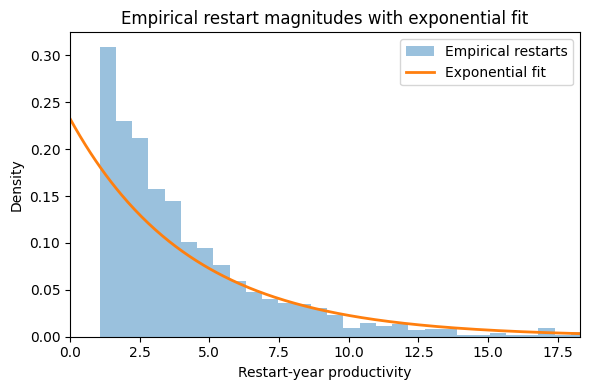

In [102]:
# Cell 7B: restart dx check

x_max = np.quantile(restart_q_empirical, 0.99)
x_grid = np.linspace(0, x_max, 300)
restart_pdf = lambda_restart * np.exp(-lambda_restart * x_grid)

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(restart_q_empirical,bins=50,density=True,alpha=0.45,label="Empirical restarts")

ax.plot(x_grid,restart_pdf,linewidth=2,label="Exponential fit")

ax.set_xlim(0, x_max)
ax.set_xlabel("Restart-year productivity")
ax.set_ylabel("Density")
ax.set_title("Empirical restart magnitudes with exponential fit")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_restartFit.png", dpi=300, bbox_inches="tight")
plt.show()


In [103]:
# Cell 8: simulation helpers

def make_ar1_year_lookup(year_ar1_params):
    return (year_ar1_params.set_index("year")[["intercept", "beta", "sigma_resid"]].to_dict("index"))

ar1_year_lookup = make_ar1_year_lookup(year_ar1_params)

def draw_exponential_positive(scale, size, rng):
    if size == 0:
        return np.array([], dtype=float)
    return np.clip(rng.exponential(scale=scale, size=size), MIN_POS_Q, None)

def draw_next_binary_state_parametric(q_current, b_current, year, rng):
    q_current = np.asarray(q_current, dtype=float)
    b_current = np.asarray(b_current, dtype=int)
    p_to_active = np.zeros(len(b_current), dtype=float)

    currently_zero = b_current == 0
    currently_active = b_current == 1

    if currently_zero.any():
        p_to_active[currently_zero] = restart_prob_by_year[year]

    if currently_active.any():
        p_drop = predict_dropout_prob(q_current[currently_active], year)
        p_to_active[currently_active] = 1 - p_drop

    p_to_active = np.clip(p_to_active, MIN_PROB, MAX_PROB)
    return rng.binomial(1, p_to_active, size=len(b_current)).astype(int)

def simulate_parametric_productivity_conditioned_hurdle(ar1_year_lookup, alpha_q0_pos=alpha_q0_pos, alpha_restart=alpha_restart, p_init_active=p_init_active, Y=Y, n=N, rng=None):

    if rng is None:
        rng = np.random.default_rng()

    trajectories = np.zeros((Y + 1, n), dtype=float)
    z_paths = np.full((Y + 1, n), np.nan, dtype=float)
    b_paths = np.zeros((Y + 1, n), dtype=int)

    b_paths[0] = rng.binomial(1, p_init_active, size=n).astype(int)
    init_active = b_paths[0] == 1
    q0 = np.zeros(n)
    q0[init_active] = draw_exponential_positive(alpha_q0_pos, init_active.sum(), rng)

    trajectories[0] = q0
    z_paths[0, init_active] = np.log(q0[init_active])

    for t in range(Y):
        q_now = trajectories[t]
        b_now = b_paths[t]
        b_next = draw_next_binary_state_parametric(q_current=q_now,b_current=b_now,year=t,rng=rng)

        q_next = np.zeros(n)
        z_next = np.full(n, np.nan)

        restart = (b_now == 0) & (b_next == 1)
        continued = (b_now == 1) & (b_next == 1)

        if restart.sum() > 0:
            q_restart = draw_exponential_positive(alpha_restart, restart.sum(), rng)
            q_next[restart] = q_restart
            z_next[restart] = np.log(q_restart)

        if continued.sum() > 0:
            intercept = ar1_year_lookup[t]["intercept"]
            beta = ar1_year_lookup[t]["beta"]
            sigma = ar1_year_lookup[t]["sigma_resid"]
            shock = rng.normal(loc=0, scale=sigma, size=continued.sum())
            z_cont = intercept + beta * z_paths[t, continued] + shock

            q_next[continued] = np.exp(z_cont)
            z_next[continued] = z_cont

        trajectories[t + 1] = q_next
        z_paths[t + 1] = z_next
        b_paths[t + 1] = b_next

    return trajectories, z_paths, b_paths

def simulate_combined_model(ar1_year_lookup, n=N, Y=Y, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return simulate_parametric_productivity_conditioned_hurdle(ar1_year_lookup=ar1_year_lookup,alpha_q0_pos=alpha_q0_pos,alpha_restart=alpha_restart,p_init_active=p_init_active,Y=Y,n=n,rng=rng)

def trajectories_to_dataframe_combined(trajs, b_paths):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({"CareerAge": np.repeat(years, len(ix)),"ix": np.tile(ix, len(years)),"pubs_adj": trajs.reshape(-1),"state": b_paths.reshape(-1),})

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["state_next"] = df_sim.groupby("ix")["state"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]
    df_sim["log_pubs_adj"] = np.where(df_sim["pubs_adj"] > 0, np.log(df_sim["pubs_adj"]), np.nan)
    df_sim["log_pubs_next"] = np.where(df_sim["pubs_adj_next"] > 0, np.log(df_sim["pubs_adj_next"]), np.nan)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna(subset=["pubs_adj_next", "state_next"]).copy()


In [104]:
# Cell 9: simulate combined hurdle AR(1)

trajs_combined, z_trajs_combined, b_trajs_combined = simulate_combined_model(ar1_year_lookup=ar1_year_lookup,n=N,Y=Y,rng=rng)

trajs = trajs_combined
b_trajs = b_trajs_combined

df_trajs = trajectories_to_dataframe_combined(trajs, b_trajs)

print("trajectory array shape:", trajs.shape)
print("binary path array shape:", b_trajs.shape)
print()
print("sim'd state fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: zero={(b_trajs[t] == 0).mean():.4f}, active={(b_trajs[t] == 1).mean():.4f}")

print()
print("sim'd positive log increments:")
print(df_trajs.loc[(df_trajs["state"] == 1) & (df_trajs["state_next"] == 1), "log_delta"].describe())


trajectory array shape: (21, 1000)
binary path array shape: (21, 1000)

sim'd state fractions:
Year 0: zero=0.2170, active=0.7830
Year 5: zero=0.1420, active=0.8580
Year 10: zero=0.1760, active=0.8240
Year 15: zero=0.1610, active=0.8390
Year 20: zero=0.1800, active=0.8200

sim'd positive log increments:
count    14729.000000
mean         0.024285
std          0.742890
min         -2.761669
25%         -0.470370
50%          0.014861
75%          0.507642
max          4.866697
Name: log_delta, dtype: float64


/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/samlunemagid/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


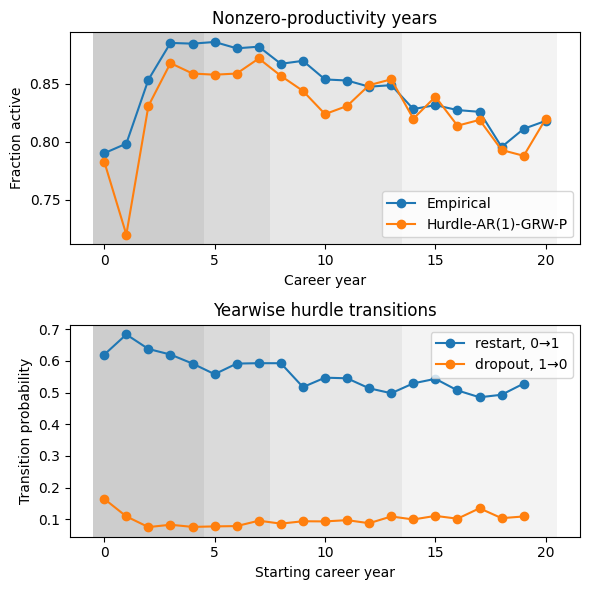

In [105]:
# Cell 10: binary path dx

emp_state_by_year = (df.groupby(age_col)["state"].agg(frac_active="mean",n="size").reset_index())

sim_state_by_year = pd.DataFrame({
    "year": np.arange(Y + 1),
    "frac_active": b_trajs_combined.mean(axis=1),
    "n": b_trajs_combined.shape[1],})

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_state_by_year["CareerAge"], emp_state_by_year["frac_active"], marker="o", label="Empirical", zorder = 3)
axes[0].plot(sim_state_by_year["year"], sim_state_by_year["frac_active"], marker="o", label=MODEL_NAME, zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Fraction active")
axes[0].set_title("Nonzero-productivity years")
axes[0].legend()

axes[1].plot(year_transition_summary["year"], year_transition_summary["P_nothing_to_something"], marker="o", label="restart, 0→1", zorder = 3)
axes[1].plot(year_transition_summary["year"], year_transition_summary["P_something_to_nothing"], marker="o", label="dropout, 1→0", zorder = 3)
axes[1].set_xlabel("Starting career year")
axes[1].set_ylabel("Transition probability")
axes[1].set_title("Yearwise hurdle transitions")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_Dx.png", dpi=300, bbox_inches="tight")
plt.show()


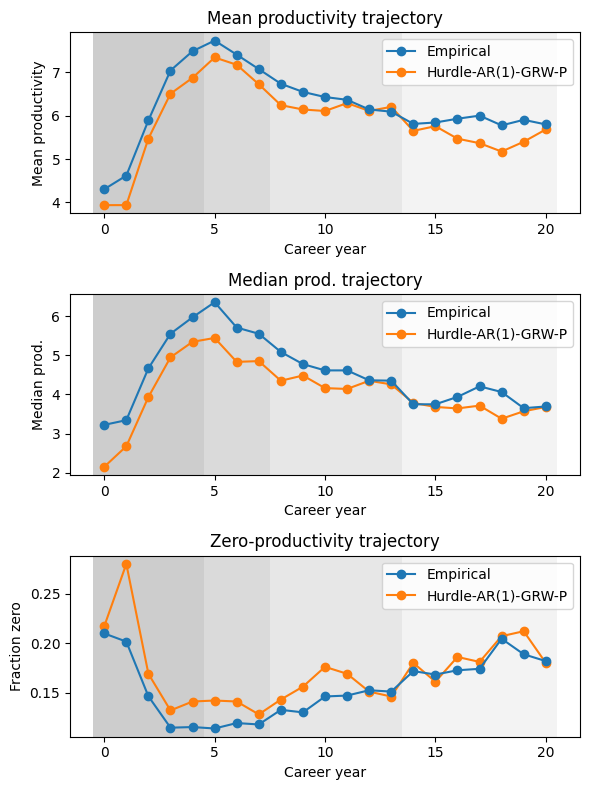

In [106]:
# Cell 11: canonical trajectory check

emp_mean = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].mean())

emp_median = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].median())

emp_frac_zero = (working_df[working_df["CareerAge"].between(0, Y)].groupby("CareerAge")["pubs_adj"].apply(lambda x: (x == 0).mean()))

sim_mean = trajs_combined.mean(axis=1)
sim_median = np.median(trajs_combined, axis=1)
sim_frac_zero = (trajs_combined == 0).mean(axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label=MODEL_NAME)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label=MODEL_NAME)
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

axes[2].plot(emp_frac_zero.index, emp_frac_zero.values, marker="o", label="Empirical", zorder = 3)
axes[2].plot(years, sim_frac_zero, marker="o", label=MODEL_NAME)
axes[2].set_xlabel("Career year")
axes[2].set_ylabel("Fraction zero")
axes[2].set_title("Zero-productivity trajectory")
axes[2].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_trajectories.png", dpi=300, bbox_inches="tight")

plt.show()


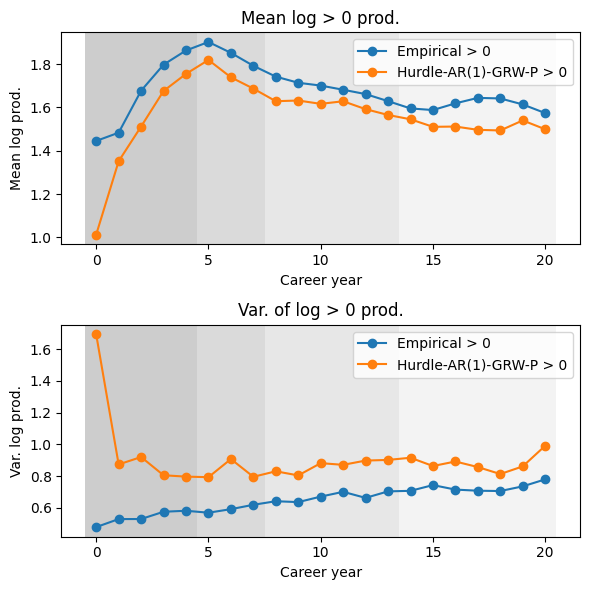

In [107]:
# Cell 12: yearwise log distrib dx

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_combined[t])

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95)})

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)
axes[0].plot(emp_year_stats["year"],emp_year_stats["mean_log_prod_pos"],marker="o",label="Empirical > 0", zorder = 3)
axes[0].plot(sim_year_stats["year"],sim_year_stats["mean_log_prod_pos"],marker="o",label=f"{MODEL_NAME} > 0", zorder = 3)
axes[0].set_title("Mean log > 0 prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(emp_year_stats["year"],emp_year_stats["var_log_prod_pos"],marker="o",label="Empirical > 0", zorder = 3)
axes[1].plot(sim_year_stats["year"],sim_year_stats["var_log_prod_pos"],marker="o", label=f"{MODEL_NAME} > 0", zorder = 3)
axes[1].set_title("Var. of log > 0 prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_posLog.png", dpi=300, bbox_inches="tight")
plt.show()


In [108]:
# Cell 13A: yearwise log-delta distrib dx func

def binned_mode(x, bins="auto"):
    x = pd.Series(x).dropna().to_numpy()

    if len(x) == 0:
        return np.nan

    if np.nanmin(x) == np.nanmax(x):
        return float(x[0])

    counts, edges = np.histogram(x, bins=bins)
    k = np.argmax(counts)

    return (edges[k] + edges[k + 1]) / 2

def make_log_delta_stats(df, year_col="CareerAge", delta_col="log_delta", Y=20):

    years = np.arange(0, Y)

    rows = []
    for t in years:
        subset = df[df[year_col] == t]
        dz = subset[delta_col].dropna()

        rows.append({
            "year": t,
            "n": len(dz),
            "mean_log_delta": dz.mean(),
            "median_log_delta": dz.median(),
            "mode_log_delta": binned_mode(dz),
            "var_log_delta": dz.var(ddof=0),
            "q25_log_delta": dz.quantile(0.25),
            "q50_log_delta": dz.quantile(0.50),
            "q75_log_delta": dz.quantile(0.75),
            "q90_log_delta": dz.quantile(0.90),
            "q95_log_delta": dz.quantile(0.95)})

    return pd.DataFrame(rows)


In [109]:
# Cell 13B: yearwise log delta stats get

emp_delta_stats = make_log_delta_stats(working_df_fit,year_col="CareerAge",delta_col="log_delta",Y=Y)

TRJ = np.asarray(trajs_combined)

if TRJ.shape[0] != Y + 1 and TRJ.shape[1] == Y + 1:
    TRJ = TRJ.T

assert TRJ.shape[0] == Y + 1, f"got {TRJ.shape}"

df_sim_delta = pd.DataFrame({"CareerAge": np.repeat(np.arange(Y), TRJ.shape[1]),"pubs_adj": TRJ[:-1, :].ravel(),"pubs_adj_next": TRJ[1:, :].ravel(),})

df_sim_delta["log_delta"] = (np.log(df_sim_delta["pubs_adj_next"] + EPS)- np.log(df_sim_delta["pubs_adj"] + EPS))

sim_delta_stats = make_log_delta_stats(df_sim_delta,year_col="CareerAge",delta_col="log_delta",Y=Y)


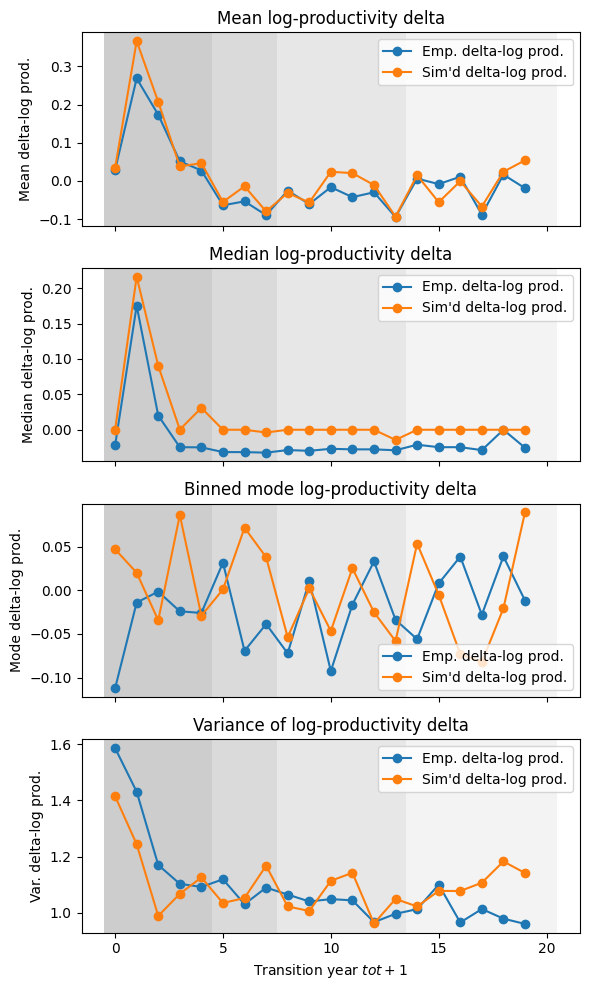

In [110]:
# Cell 13C: plot yearwise log-delta moments

fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)


axes[0].plot(emp_delta_stats["year"],emp_delta_stats["mean_log_delta"],marker="o", label="Emp. delta-log prod.", zorder=3)
axes[0].plot(sim_delta_stats["year"],sim_delta_stats["mean_log_delta"],marker="o",label="Sim'd delta-log prod.", zorder=3)
axes[0].set_title("Mean log-productivity delta")
axes[0].set_ylabel("Mean delta-log prod.")
axes[0].legend()

axes[1].plot(emp_delta_stats["year"],emp_delta_stats["median_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[1].plot(sim_delta_stats["year"],sim_delta_stats["median_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[1].set_title("Median log-productivity delta")
axes[1].set_ylabel("Median delta-log prod.")
axes[1].legend()

axes[2].plot(emp_delta_stats["year"],emp_delta_stats["mode_log_delta"],marker="o",label="Emp. delta-log prod.",zorder=3)
axes[2].plot(sim_delta_stats["year"],sim_delta_stats["mode_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[2].set_title("Binned mode log-productivity delta")
axes[2].set_ylabel("Mode delta-log prod.")
axes[2].legend()

axes[3].plot(emp_delta_stats["year"],emp_delta_stats["var_log_delta"],marker="o",label="Emp. delta-log prod.", zorder=3)
axes[3].plot(sim_delta_stats["year"],sim_delta_stats["var_log_delta"],marker="o",label="Sim'd delta-log prod.",zorder=3)
axes[3].set_title("Variance of log-productivity delta")
axes[3].set_xlabel("Transition year $t \to t+1$")
axes[3].set_ylabel("Var. delta-log prod.")
axes[3].legend()

plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_logDeltaMoments.png",dpi=300,bbox_inches="tight")
plt.show()


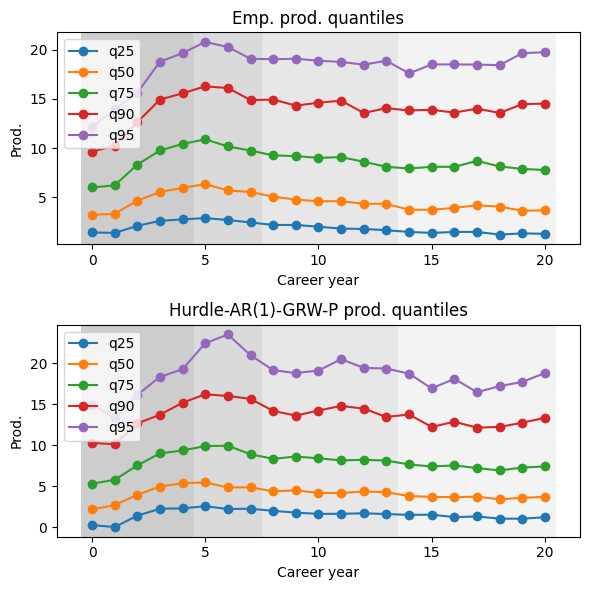

In [111]:
# Cell 14: yearwise quantile distrib dx

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(start - 0.5,end + 0.5,facecolor=shade,alpha=0.65,zorder=0)

for qcol in qcols:
    axes[0].plot(emp_year_stats["year"],emp_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()
for qcol in qcols:
    axes[1].plot(sim_year_stats["year"],sim_year_stats[qcol],marker="o",label=qcol.replace("_prod", ""), zorder = 3)

axes[1].set_title(f"{MODEL_NAME} prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()


plt.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()


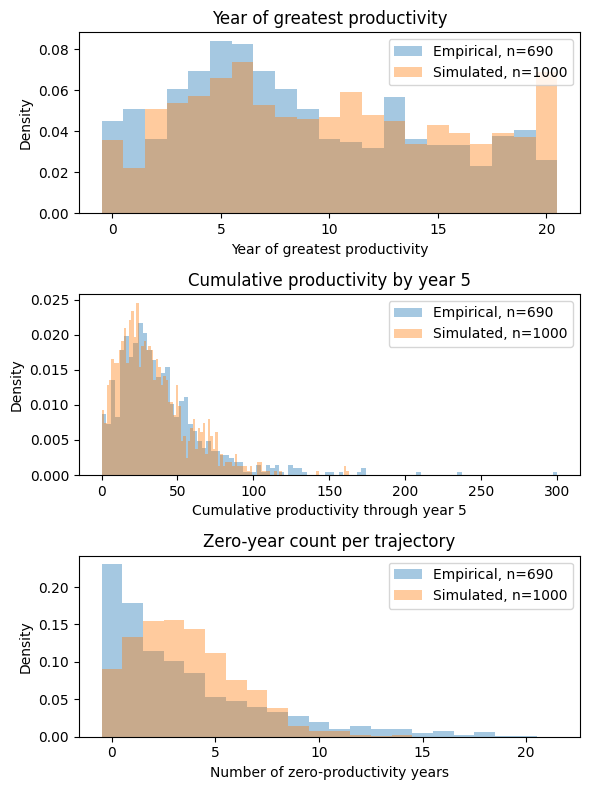

Full empirical trajectories: 690
Simulated trajectories: 1000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.10414492753623189), pvalue=np.float64(0.00025791907468812955), statistic_location=np.int64(9), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.0761159420289855), pvalue=np.float64(0.016503607375836223), statistic_location=np.float64(23.96578289197463), statistic_sign=np.int8(-1))
KS zero-year count: KstestResult(statistic=np.float64(0.18569565217391304), pvalue=np.float64(8.687798500083487e-13), statistic_location=np.int64(1), statistic_sign=np.int8(1))


In [112]:
# Cell 15: dx, norm'd

emp_panel = (working_df[working_df["CareerAge"].between(0, Y)].pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj"))

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)
emp_zero_count = (emp_panel_full == 0).sum(axis=1)

sim_year_max = np.argmax(trajs_combined, axis=0)
sim_cum_y5 = trajs_combined[0:6, :].sum(axis=0)
sim_zero_count = (trajs_combined == 0).sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)
ks_zero_count = stats.ks_2samp(emp_zero_count, sim_zero_count)

fig, axes = plt.subplots(3, 1, figsize=(6, 8))

axes[0].hist(emp_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True,label=f"Empirical, n={len(emp_year_max)}")

axes[0].hist(sim_year_max,bins=np.arange(-0.5, Y + 1.5, 1),alpha=0.4,density=True, label=f"Simulated, n={len(sim_year_max)}")

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(emp_cum_y5,bins=100,alpha=0.4,density=True,label=f"Empirical, n={len(emp_cum_y5)}")

axes[1].hist(sim_cum_y5,bins=100,alpha=0.4,density=True,label=f"Simulated, n={len(sim_cum_y5)}")

axes[1].set_xlabel("Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

axes[2].hist(emp_zero_count,bins=np.arange(-0.5, Y + 2.5, 1),alpha=0.4,density=True, label=f"Empirical, n={len(emp_zero_count)}")

axes[2].hist(sim_zero_count,bins=np.arange(-0.5, Y + 2.5, 1),alpha=0.4,density=True,label=f"Simulated, n={len(sim_zero_count)}")

axes[2].set_xlabel("Number of zero-productivity years")
axes[2].set_ylabel("Density")
axes[2].set_title("Zero-year count per trajectory")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / f"{MODEL_TAG}_distribs.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_combined.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)
print("KS zero-year count:", ks_zero_count)


In [113]:
# Cell 18: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "empirical_frac_zero_y0": emp_frac_zero.loc[0],
    "empirical_frac_zero_y5": emp_frac_zero.loc[5],
    "empirical_frac_zero_y10": emp_frac_zero.loc[10],
    "empirical_frac_zero_y20": emp_frac_zero.loc[20],
    "simulated_frac_zero_y0": sim_frac_zero[0],
    "simulated_frac_zero_y5": sim_frac_zero[5],
    "simulated_frac_zero_y10": sim_frac_zero[10],
    "simulated_frac_zero_y20": sim_frac_zero[20],
    "dropout_gamma_log1p_q": fitted_gamma,
    "dropout_nll": opt.fun,
    "p_init_active": p_init_active,
    "alpha_q0_pos": alpha_q0_pos,
    "lambda_q0_pos": lambda_q0_pos,
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "simulated_y20_q95": np.quantile(trajs_combined[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_combined[20], 0.99),
    "simulated_y20_max": np.max(trajs_combined[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
    "ks_zero_count_stat": ks_zero_count.statistic,
    "ks_zero_count_p": ks_zero_count.pvalue}

summary_df = pd.DataFrame([summary])

print("Yearwise unconditioned transition summary, retained for comparison")
display(year_transition_summary.round(3))

print("Parametric monotone dropout model summary")
display(dropout_param_summary.round(4))

print("Yearwise positive-only AR(1) params")
display(year_ar1_params)

print("Exponential initial/restart params")
display(pd.DataFrame([{
    "alpha_restart": alpha_restart,
    "lambda_restart": lambda_restart,
    "restart_n": len(restart_q_empirical),
    "alpha_q0_pos": alpha_q0_pos,
    "lambda_q0_pos": lambda_q0_pos,
    "p_init_active": p_init_active,
    "dropout_gamma_log1p_q": fitted_gamma,}]))

print("Summary")
display(summary_df)


Yearwise unconditioned transition summary, retained for comparison


,year,n,P_nothing_to_nothing,P_nothing_to_something,P_something_to_nothing,P_something_to_something
0,0,2067,0.380,0.620,0.164,0.836
1,1,2143,0.316,0.684,0.109,0.891
2,2,2202,0.362,0.638,0.075,0.925
3,3,2247,0.380,0.620,0.082,0.918
4,4,2259,0.408,0.592,0.076,0.924
5,5,2200,0.442,0.558,0.077,0.923
6,6,2142,0.408,0.592,0.078,0.922
7,7,2059,0.407,0.593,0.095,0.905
8,8,1985,0.407,0.593,0.086,0.914
9,9,1895,0.483,0.517,0.094,0.906


Parametric monotone dropout model summary


,year,n_active_transitions,observed_dropout_rate,restart_prob_if_zero,dropout_intercept,dropout_gamma_log1p_q,pred_drop_q25,pred_drop_q50,pred_drop_q75,pred_drop_q95
0,0,1633,0.1641,0.6198,0.2482,1.1886,0.1876,0.1156,0.0688,0.0338
1,1,1710,0.1088,0.6836,-0.2217,1.1886,0.1261,0.0755,0.0441,0.0214
2,2,1879,0.0750,0.6378,-0.4681,1.1886,0.1014,0.0600,0.0348,0.0168
3,3,1989,0.0825,0.6202,-0.2655,1.1886,0.1214,0.0725,0.0423,0.0205
4,4,1997,0.0756,0.5916,-0.2912,1.1886,0.1187,0.0708,0.0413,0.0200
5,5,1942,0.0772,0.5581,-0.2168,1.1886,0.1267,0.0758,0.0443,0.0215
6,6,1880,0.0782,0.5916,-0.2556,1.1886,0.1224,0.0732,0.0427,0.0207
7,7,1806,0.0952,0.5929,-0.0814,1.1886,0.1424,0.0859,0.0504,0.0245
8,8,1710,0.0860,0.5927,-0.2522,1.1886,0.1228,0.0734,0.0429,0.0208
9,9,1636,0.0935,0.5174,-0.1788,1.1886,0.1309,0.0786,0.0460,0.0223


Yearwise positive-only AR(1) params


,year,n,intercept,beta,sigma_resid,var_resid,implied_stationary_mean_log,implied_stationary_var_log,mean_resid,sd_resid
0,0,1365,0.819365,0.487050,0.659691,0.435192,1.597357,0.570532,-2.931314e-16,0.659691
1,1,1524,1.012746,0.480930,0.632968,0.400649,1.951079,0.521199,-7.960969e-16,0.632968
2,2,1738,0.883562,0.565076,0.635208,0.403490,2.031531,0.592766,-4.497106e-17,0.635208
3,3,1825,0.864084,0.564572,0.626882,0.392981,1.984447,0.576845,9.616661e-16,0.626882
4,4,1846,0.861894,0.565928,0.611380,0.373786,1.985604,0.549907,-5.032690e-16,0.611380
5,5,1792,0.762904,0.571968,0.635388,0.403717,1.782353,0.600009,7.335402e-17,0.635388
6,6,1733,0.688805,0.599914,0.628445,0.394943,1.721643,0.616999,-5.289095e-16,0.628445
7,7,1634,0.672751,0.599344,0.651036,0.423848,1.679121,0.661448,-8.283867e-16,0.651036
8,8,1563,0.695445,0.591099,0.641449,0.411457,1.700767,0.632424,2.312787e-16,0.641449
9,9,1483,0.641599,0.618118,0.652205,0.425371,1.680096,0.688380,4.012674e-17,0.652205


Exponential initial/restart params


,alpha_restart,lambda_restart,restart_n,alpha_q0_pos,lambda_q0_pos,p_init_active,dropout_gamma_log1p_q
0,4.299784,0.23257,3061,5.447328,0.183576,0.790237,1.188553


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,restart_n,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p,ks_zero_count_stat,ks_zero_count_p
0,4.304679,7.729319,6.428626,5.797863,3.938006,7.340079,6.10701,5.681778,3.225469,6.352937,...,3061,18.767096,32.462998,78.077742,0.104145,0.000258,0.076116,0.016504,0.185696,8.687799e-13


In [114]:
# Cell 19: save outputs

year_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_yearTransitionSummary.csv", index=False)
stage_transition_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageTransitionSummary.csv", index=False)
dropout_param_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramDropoutSummary.csv", index=False)
year_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_posYearLog.csv", index=False)
global_ar1_params.to_csv(RESULTS / f"{MODEL_TAG}_pos_globalLog.csv", index=False)
emp_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / f"{MODEL_TAG}_simYearStats.csv", index=False)
emp_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_empLogDeltaStats.csv", index=False)
sim_delta_stats.to_csv(RESULTS / f"{MODEL_TAG}_simLogDeltaStats.csv", index=False)
summary_df.to_csv(RESULTS / f"{MODEL_TAG}_Summary.csv", index=False)

def matrix_dict_to_frame(matrix_dict, level_name):
    rows = []
    for key, mat in matrix_dict.items():
        rows.append({
            level_name: key,
            "P_nothing_to_nothing": mat.loc[0, 0],
            "P_nothing_to_something": mat.loc[0, 1],
            "P_something_to_nothing": mat.loc[1, 0],
            "P_something_to_something": mat.loc[1, 1],})
    return pd.DataFrame(rows)

matrix_dict_to_frame(year_P, "year").to_csv(RESULTS / f"{MODEL_TAG}_yearPMatrices.csv", index=False)
matrix_dict_to_frame(stage_P, "stage").to_csv(RESULTS / f"{MODEL_TAG}_stagePMatrices.csv", index=False)

pd.DataFrame({"year": np.arange(Y),"restart_prob_if_zero": restart_prob_by_year,"dropout_intercept": fitted_intercepts,"dropout_gamma_log1p_q": fitted_gamma,}).to_csv(RESULTS / f"{MODEL_TAG}_paramHurdleParams.csv", index=False)

with open(RESULTS / f"{MODEL_TAG}_report.txt", "w") as f:
    f.write("parametric productivity-conditioned hurdle yearwise AR(1) report\n")
    f.write("\n\n")
    f.write("Model\n")
    f.write("\n")
    f.write("B_0 ~ Bernoulli(p_init_active).\n")
    f.write("Q_0 ~ Exponential(lambda_0) if B_0=1; otherwise Q_0=0.\n")
    f.write("If B_t=0, B_{t+1} ~ Bernoulli(r_t), where r_t is the yearwise restart probability.\n")
    f.write("If B_t=1, Pr(B_{t+1}=0 | Q_t) = logistic(a_t - gamma log(1 + Q_t)), gamma >= 0.\n")
    f.write("Q_{t+1} = 0 if B_{t+1}=0.\n")
    f.write("Q_{t+1} ~ Exponential(lambda_R) if B_t=0 and B_{t+1}=1.\n")
    f.write("log(Q_{t+1}) = intercept_t + beta_t log(Q_t) + error_t if B_t=1 and B_{t+1}=1.\n")
    f.write("error_t ~ Normal(0, sigma_t^2).\n\n")
    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n")
    f.write(f"p_init_active = {p_init_active}\n")
    f.write(f"alpha_q0_pos = {alpha_q0_pos}\n")
    f.write(f"lambda_q0_pos = {lambda_q0_pos}\n")
    f.write(f"alpha_restart = {alpha_restart}\n")
    f.write(f"lambda_restart = {lambda_restart}\n")
    f.write(f"dropout_gamma_log1p_q = {fitted_gamma}\n")
    f.write(f"dropout_nll = {opt.fun}\n\n")
    f.write("Parametric dropout summary\n")
    f.write("\n")
    f.write(dropout_param_summary.to_string(index=False))
    f.write("\n\nYearwise binary transition summary, retained for comparison\n")
    f.write("\n")
    f.write(year_transition_summary.to_string(index=False))
    f.write("\n\nYearwise positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(year_ar1_params.to_string(index=False))
    f.write("\n\nGlobal positive-only AR(1) parameters\n")
    f.write("\n")
    f.write(global_ar1_params.to_string(index=False))
    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))


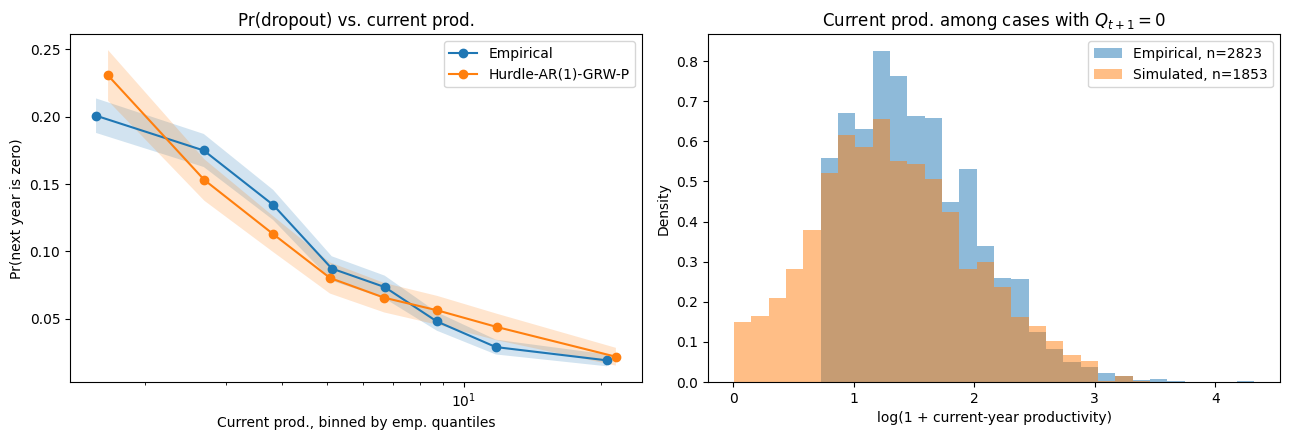

Empirical dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",3760,0.200798,1.558408,1.502068,Empirical,1.558408,0.006533,0.187993,0.213603
1,"(2.181, 3.229]",3687,0.174939,2.687266,2.644809,Empirical,2.687266,0.006257,0.162676,0.187202
2,"(3.229, 4.419]",3575,0.134545,3.815607,3.811037,Empirical,3.815607,0.005707,0.123359,0.145731
3,"(4.419, 5.829]",3700,0.087297,5.131218,5.084822,Empirical,5.131218,0.004640,0.078202,0.096393
4,"(5.829, 7.622]",3631,0.073533,6.704440,6.691238,Empirical,6.704440,0.004332,0.065044,0.082023
5,"(7.622, 10.037]",3711,0.047966,8.732543,8.706188,Empirical,8.732543,0.003508,0.041090,0.054841
6,"(10.037, 14.001]",3592,0.028953,11.763405,11.657458,Empirical,11.763405,0.002798,0.023470,0.034437
7,"(14.001, 80.687]",3666,0.019094,20.622869,18.392702,Empirical,20.622869,0.002260,0.014664,0.023525


Simulated dropout by current productivity bin:


,prod_bin,n,dropout_rate,mean_q_t,median_q_t,source,bin_mid,se,lower,upper
0,"(1.0890000000000002, 2.181]",1925,0.230649,1.656307,1.664746,Simulated,1.656307,0.009601,0.211831,0.249468
1,"(2.181, 3.229]",2097,0.153076,2.694180,2.689046,Simulated,2.694180,0.007863,0.137665,0.168487
2,"(3.229, 4.419]",2164,0.113216,3.804484,3.799746,Simulated,3.804484,0.006811,0.099866,0.126567
3,"(4.419, 5.829]",2118,0.080264,5.086392,5.077195,Simulated,5.086392,0.005904,0.068693,0.091836
4,"(5.829, 7.622]",1966,0.065615,6.690524,6.670647,Simulated,6.690524,0.005584,0.054670,0.076561
5,"(7.622, 10.037]",1779,0.056211,8.755748,8.731940,Simulated,8.755748,0.005461,0.045508,0.066915
6,"(10.037, 14.001]",1664,0.043870,11.822209,11.766413,Simulated,11.822209,0.005021,0.034030,0.053711
7,"(14.001, 80.687]",1882,0.021785,21.580766,18.745170,Simulated,21.580766,0.003365,0.015190,0.028381


In [115]:
# conditioned dropout 

emp_dx = working_df_fit.loc[working_df_fit["pubs_adj"].notna() & working_df_fit["pubs_adj_next"].notna(),["CareerAge", "pubs_adj", "pubs_adj_next"]].copy()

emp_dx = emp_dx.loc[emp_dx["pubs_adj"] > 0].copy()
emp_dx["drops_to_zero"] = (emp_dx["pubs_adj_next"] == 0).astype(int)


sim_dx = pd.DataFrame({"CareerAge": np.repeat(np.arange(Y), trajs_combined.shape[1]),"pubs_adj": trajs_combined[:-1, :].ravel(),"pubs_adj_next": trajs_combined[1:, :].ravel()})

sim_dx = sim_dx.loc[sim_dx["pubs_adj"] > 0].copy()
sim_dx["drops_to_zero"] = (sim_dx["pubs_adj_next"] == 0).astype(int)

n_bins = 8

bin_edges = np.quantile(emp_dx["pubs_adj"], np.linspace(0, 1, n_bins + 1))

bin_edges = np.unique(bin_edges)

if len(bin_edges) < 3:
    raise ValueError("Not enough unique emp bin edges")

emp_dx["prod_bin"] = pd.cut(emp_dx["pubs_adj"],bins=bin_edges,include_lowest=True,duplicates="drop")

sim_dx["prod_bin"] = pd.cut(sim_dx["pubs_adj"],bins=bin_edges,include_lowest=True,duplicates="drop")

def summarize_dropout_by_bin(df, label):
    out = (df.groupby("prod_bin", observed=False).agg(n=("drops_to_zero", "size"),dropout_rate=("drops_to_zero", "mean"),mean_q_t=("pubs_adj", "mean"),median_q_t=("pubs_adj", "median")).reset_index())

    out["source"] = label
    out["bin_mid"] = out["mean_q_t"]

    out["se"] = np.sqrt(out["dropout_rate"] * (1 - out["dropout_rate"]) / out["n"])
    out["lower"] = np.clip(out["dropout_rate"] - 1.96 * out["se"], 0, 1)
    out["upper"] = np.clip(out["dropout_rate"] + 1.96 * out["se"], 0, 1)

    return out

emp_bin_summary = summarize_dropout_by_bin(emp_dx, "Empirical")
sim_bin_summary = summarize_dropout_by_bin(sim_dx, "Simulated")

dropout_bin_summary = pd.concat([emp_bin_summary, sim_bin_summary], ignore_index=True)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(emp_bin_summary["bin_mid"],emp_bin_summary["dropout_rate"],marker="o",label="Empirical")

axes[0].fill_between(emp_bin_summary["bin_mid"],emp_bin_summary["lower"],emp_bin_summary["upper"],alpha=0.20)

axes[0].plot(sim_bin_summary["bin_mid"],sim_bin_summary["dropout_rate"],marker="o",label=MODEL_NAME)

axes[0].fill_between(sim_bin_summary["bin_mid"],sim_bin_summary["lower"],sim_bin_summary["upper"],alpha=0.20)

axes[0].set_xlabel("Current prod., binned by emp. quantiles")
axes[0].set_ylabel("Pr(next year is zero)")
axes[0].set_title("Pr(dropout) vs. current prod.")
axes[0].legend()

axes[0].set_xscale("log")

emp_prezero = emp_dx.loc[emp_dx["drops_to_zero"] == 1, "pubs_adj"]
sim_prezero = sim_dx.loc[sim_dx["drops_to_zero"] == 1, "pubs_adj"]

hist_bins = np.histogram_bin_edges(np.log1p(pd.concat([emp_prezero, sim_prezero])),bins=30)

axes[1].hist(np.log1p(emp_prezero),bins=hist_bins,density=True,alpha=0.5,label=f"Empirical, n={len(emp_prezero)}")

axes[1].hist(np.log1p(sim_prezero),bins=hist_bins,density=True,alpha=0.5,label=f"Simulated, n={len(sim_prezero)}")

axes[1].set_xlabel("log(1 + current-year productivity)")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Current prod. among cases with $Q_{t+1}=0$")
axes[1].legend()

plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_paramCondProdDropout.png",dpi=300,bbox_inches="tight")

dropout_bin_summary.to_csv(RESULTS / f"{MODEL_TAG}_paramCondProdDropoutSummary.csv", index=False)

print("Empirical dropout by current productivity bin:")
display(emp_bin_summary)

print("Simulated dropout by current productivity bin:")
display(sim_bin_summary)


In [116]:
OUT = PROJ_ROOT / "data" / 'trajectory_correlation_data'


TRJ =  trajs_combined      

TRJ = np.asarray(TRJ)
if TRJ.shape[0] != 21 and TRJ.shape[1] == 21:
    TRJ = TRJ.T

assert TRJ.shape[0] == 21, f"expected 21 years, got {TRJ.shape}"

save_path = OUT / f"{MODEL_TAG}_trajs.npy"
np.save(save_path, TRJ)

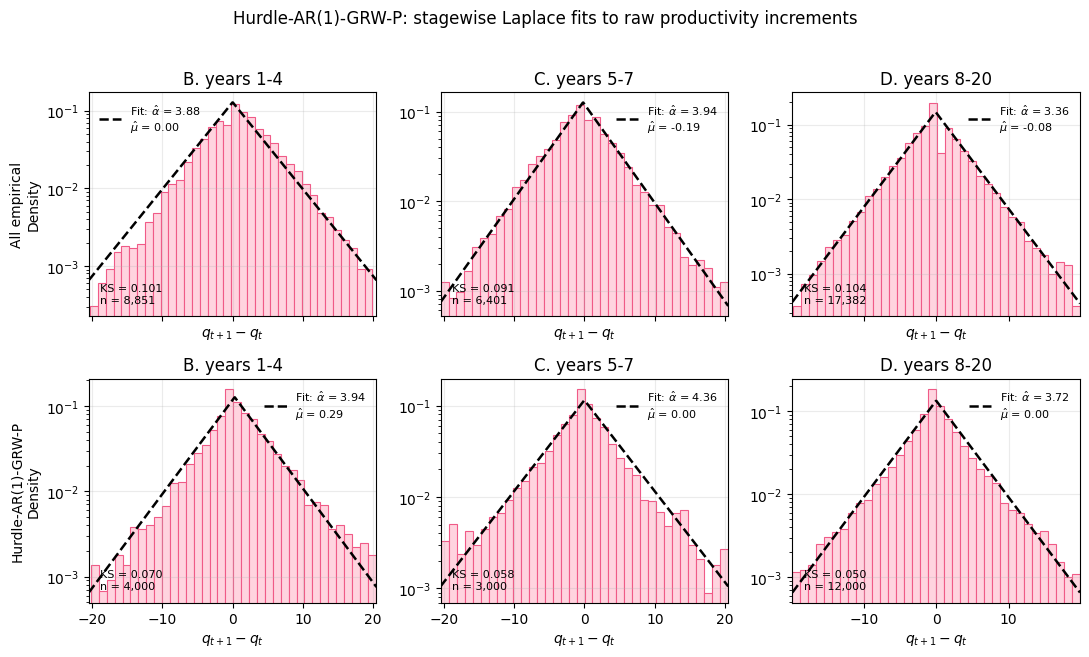

,model,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99
0,All empirical,empirical,B. years 1-4,8851,0.000000,3.879470,0.101040,0.756686,5.414004,-13.371327,0.000000,15.428888
1,All empirical,empirical,C. years 5-7,6401,-0.190708,3.937165,0.090950,-0.429310,5.622345,-15.275857,-0.190708,15.502144
2,All empirical,empirical,D. years 8-20,17382,-0.079308,3.363053,0.104041,-0.220967,4.886889,-13.966737,-0.079308,13.732907
3,Hurdle-AR(1)-GRW-P,simulated,B. years 1-4,4000,0.292318,3.941307,0.070052,0.850222,6.212664,-15.768080,0.292318,19.948314
4,Hurdle-AR(1)-GRW-P,simulated,C. years 5-7,3000,0.000000,4.355451,0.058356,-0.366316,6.883757,-20.181216,0.000000,20.014794
5,Hurdle-AR(1)-GRW-P,simulated,D. years 8-20,12000,0.000000,3.724667,0.049715,-0.046613,6.301262,-18.341334,0.000000,19.296896


In [117]:
# cell 17: laplace

stage_years = {
    "B. years 1-4": np.arange(1, 5),
    "C. years 5-7": np.arange(5, 8),
    "D. years 8-20": np.arange(8, Y)}

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))
    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def sim_stage_dx(trj, yrs):
    dx = trj[1:, :] - trj[:-1, :]
    return dx[yrs, :].ravel()

def emp_stage_dx(working_df, yrs):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    keep &= emp_dx["CareerAge"].isin(yrs)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

plot_sources = [(MODEL_NAME, "simulated", TRJ)]

plot_sources = [("All empirical", "empirical", None)] + plot_sources

laplace_rows = []

xlims = {}
for stage, yrs in stage_years.items():
    pooled = []
    pooled.append(emp_stage_dx(working_df, yrs))

    pooled.append(sim_stage_dx(TRJ, yrs))

    pooled = np.concatenate([x for x in pooled if len(x) > 0])
    lo, hi = np.quantile(pooled, [0.005, 0.995])
    lim = max(abs(lo), abs(hi), 1)
    xlims[stage] = (-lim, lim)

fig, axes = plt.subplots(len(plot_sources), 3, figsize=(11, 3.2 * len(plot_sources)), sharex="col", sharey=False)

if len(plot_sources) == 1:
    axes = np.array([axes])

for r, (source_name, source_type, trj) in enumerate(plot_sources):
    for c, (stage, yrs) in enumerate(stage_years.items()):
        ax = axes[r, c]

        if source_type == "empirical":
            x = emp_stage_dx(working_df, yrs)
        else:
            x = sim_stage_dx(trj, yrs)

        mu, alpha, ks, n = laplace_fit(x)
        lo, hi = xlims[stage]
        x_plot = x[(x >= lo) & (x <= hi)]

        ax.hist(x_plot,bins=36,density=True,color="#ffd4df",edgecolor="#f05a87",linewidth=0.8)

        xx = np.linspace(lo, hi, 600)
        ax.plot(xx,laplace_pdf(xx, mu, alpha),linestyle="--",color="black",linewidth=1.8,label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}")

        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
        ax.set_title(stage)
        ax.set_xlabel(r"$q_{t+1} - q_t$")

        if c == 0:
            ax.set_ylabel(f"{source_name}\nDensity")

        ax.text(0.04,0.06,f"KS = {ks:.3f}\nn = {n:,}",transform=ax.transAxes,fontsize=8)

        laplace_rows.append({
            "model": source_name,
            "source": source_type,
            "stage": stage,
            "n": n,
            "mu_hat": mu,
            "alpha_hat": alpha,
            "ks_stat": ks,
            "mean": np.mean(x),
            "sd": np.std(x, ddof=0),
            "q01": np.quantile(x, 0.01),
            "q50": np.quantile(x, 0.50),
            "q99": np.quantile(x, 0.99)})

fig.suptitle(f"{MODEL_NAME}: stagewise Laplace fits to raw productivity increments", y=1.02)
fig.tight_layout()

plt.savefig(FIGURES / f"{MODEL_TAG}_stageRawIncrementLaplace.png", dpi=300, bbox_inches="tight")
plt.show()

laplace_stage_summary = pd.DataFrame(laplace_rows)
laplace_stage_summary.to_csv(RESULTS / f"{MODEL_TAG}_stageRawIncrementLaplace.csv", index=False)
laplace_stage_summary

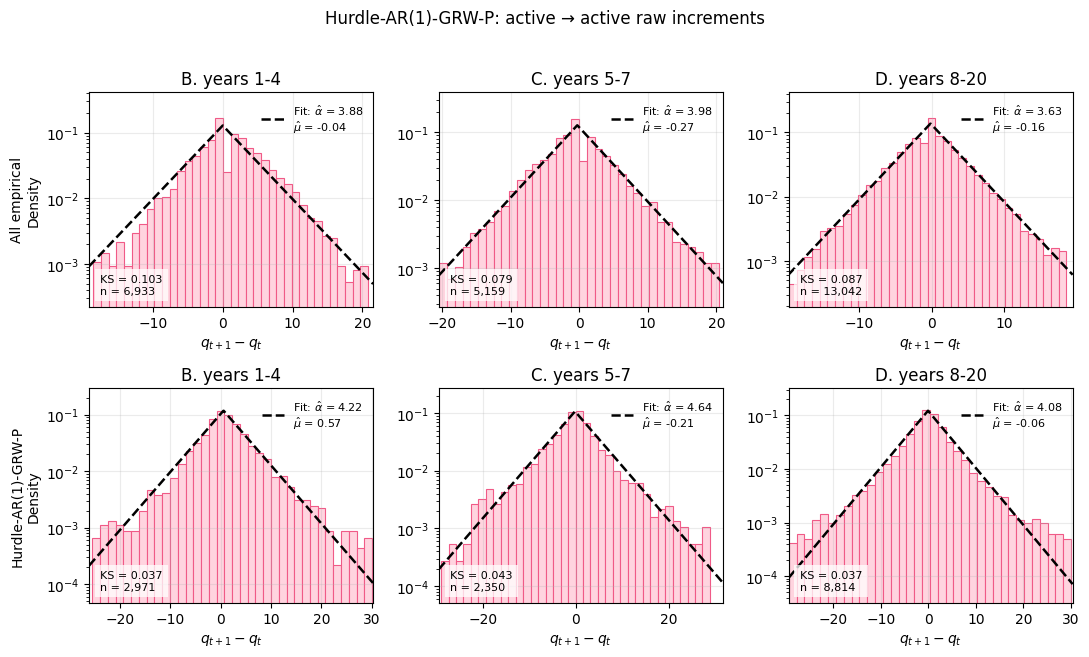

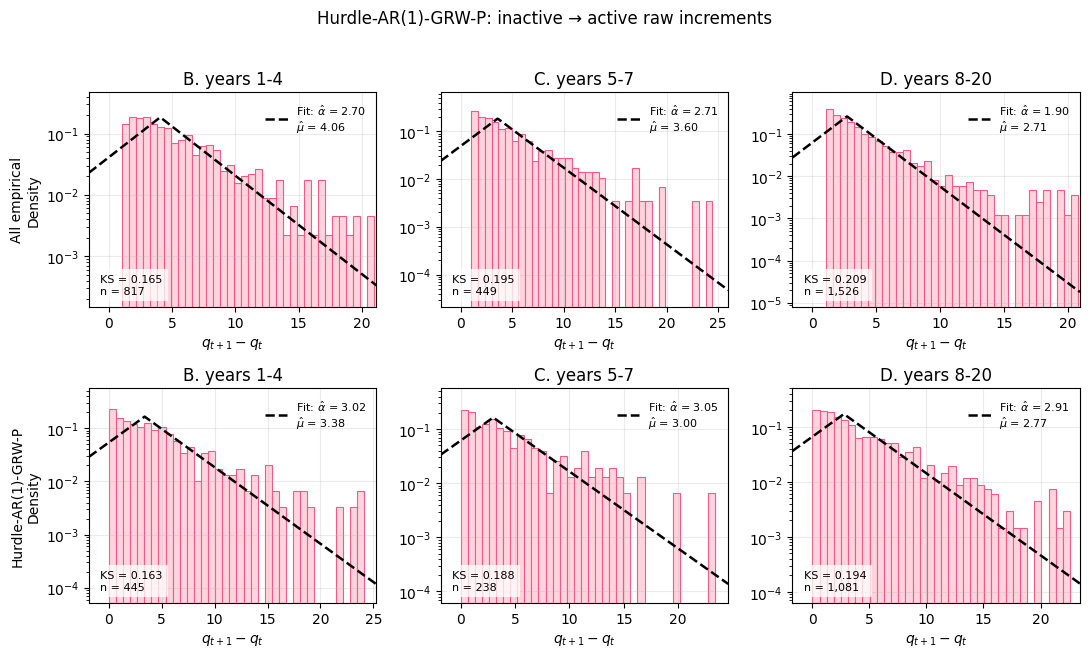

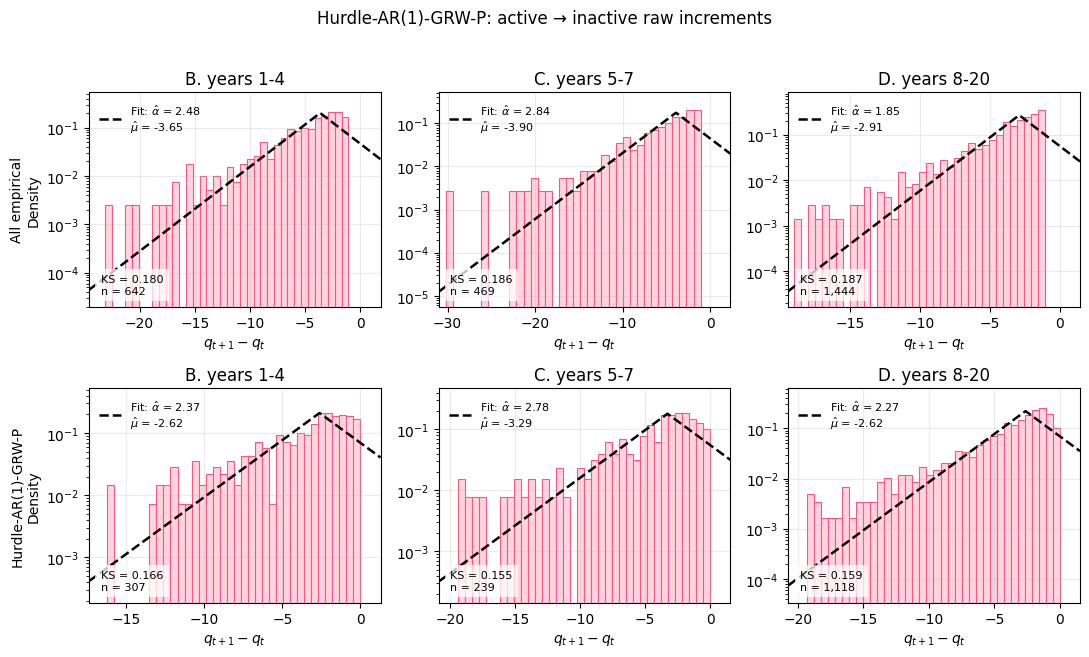

,source,stage,n,mu_hat,alpha_hat,ks_stat,mean,sd,q01,q50,q99,transition,transition_label,emp_q01,emp_q99,frac_outside_emp_1_99
1,Hurdle-AR(1)-GRW-P,B. years 1-4,2971,0.567498,4.224851,0.036702,0.859567,6.619569,-17.811389,0.567498,20.361027,active_to_active,active → active,-12.944834,14.963747,0.048132
0,empirical,B. years 1-4,6933,-0.041633,3.880758,0.102863,0.801682,5.383436,-12.944834,-0.041633,14.963747,active_to_active,active → active,-12.944834,14.963747,NaN
3,Hurdle-AR(1)-GRW-P,C. years 5-7,2350,-0.205198,4.639444,0.042852,-0.446541,7.249320,-21.126549,-0.205198,21.080923,active_to_active,active → active,-15.039792,15.342719,0.053191
2,empirical,C. years 5-7,5159,-0.274955,3.977838,0.079150,-0.483646,5.607226,-15.039792,-0.274955,15.342719,active_to_active,active → active,-15.039792,15.342719,NaN
5,Hurdle-AR(1)-GRW-P,D. years 8-20,8814,-0.062883,4.079023,0.037466,-0.109204,6.809985,-20.746351,-0.062883,21.304855,active_to_active,active → active,-14.437689,14.204638,0.045382
4,empirical,D. years 8-20,13042,-0.161491,3.626348,0.087203,-0.304683,5.165246,-14.437689,-0.161491,14.204638,active_to_active,active → active,-14.437689,14.204638,NaN
13,Hurdle-AR(1)-GRW-P,B. years 1-4,307,-2.621031,2.371725,0.166226,-3.735786,3.300236,-13.234739,-2.621031,-0.044419,active_to_inactive,active → inactive,-18.394683,-1.231551,0.208469
12,empirical,B. years 1-4,642,-3.651052,2.483994,0.180132,-4.898404,3.845452,-18.394683,-3.651052,-1.231551,active_to_inactive,active → inactive,-18.394683,-1.231551,NaN
15,Hurdle-AR(1)-GRW-P,C. years 5-7,239,-3.285927,2.779410,0.155002,-4.597935,4.147165,-18.846807,-3.285927,-0.122784,active_to_inactive,active → inactive,-21.927045,-1.146671,0.129707
14,empirical,C. years 5-7,469,-3.902057,2.836703,0.185601,-5.185207,4.451195,-21.927045,-3.902057,-1.146671,active_to_inactive,active → inactive,-21.927045,-1.146671,NaN


In [118]:
# Cell 19B: transition-specific raw increment Laplace dx


ACTIVE_TOL = 0

transition_classes = {
    "active_to_active": "active → active",
    "inactive_to_active": "inactive → active",
    "active_to_inactive": "active → inactive",
    "inactive_to_inactive": "inactive → inactive"}

plot_transitions = [
    "active_to_active",
    "inactive_to_active",
    "active_to_inactive"]

def laplace_fit(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return np.nan, np.nan, np.nan, 0

    mu = np.median(x)
    alpha = np.mean(np.abs(x - mu))

    if alpha <= 0 or not np.isfinite(alpha):
        return mu, alpha, np.nan, len(x)

    ks = stats.kstest(x, "laplace", args=(mu, alpha)).statistic
    return mu, alpha, ks, len(x)

def laplace_pdf(x, mu, alpha):
    return (1 / (2 * alpha)) * np.exp(-np.abs(x - mu) / alpha)

def transition_label(q0, q1):
    active0 = q0 > ACTIVE_TOL
    active1 = q1 > ACTIVE_TOL

    out = np.full(q0.shape, "inactive_to_inactive", dtype=object)
    out[active0 & active1] = "active_to_active"
    out[(~active0) & active1] = "inactive_to_active"
    out[active0 & (~active1)] = "active_to_inactive"

    return out

def sim_transition_dx(trj, yrs, transition):
    q0 = trj[:-1, :]
    q1 = trj[1:, :]
    dx = q1 - q0
    lab = transition_label(q0, q1)

    keep_year = np.isin(np.arange(q0.shape[0]), yrs)[:, None]
    keep = keep_year & (lab == transition)

    return dx[keep]

def emp_transition_frame(working_df):
    emp_dx = working_df.sort_values(["dblp_id", "CareerAge"]).copy()
    emp_dx["pubs_adj_next"] = emp_dx.groupby("dblp_id")["pubs_adj"].shift(-1)
    emp_dx["CareerAge_next"] = emp_dx.groupby("dblp_id")["CareerAge"].shift(-1)
    emp_dx["raw_delta"] = emp_dx["pubs_adj_next"] - emp_dx["pubs_adj"]

    keep = emp_dx["CareerAge_next"].eq(emp_dx["CareerAge"] + 1)
    emp_dx = emp_dx.loc[keep].copy()

    q0 = emp_dx["pubs_adj"].to_numpy()
    q1 = emp_dx["pubs_adj_next"].to_numpy()

    emp_dx["transition"] = transition_label(q0, q1)

    return emp_dx

def emp_transition_dx(emp_dx, yrs, transition):
    keep = emp_dx["CareerAge"].isin(yrs)
    keep &= emp_dx["transition"].eq(transition)

    return emp_dx.loc[keep, "raw_delta"].dropna().to_numpy()

def panel_xlim(x, q=0.995, pad=0.08):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

    if len(x) == 0:
        return -1, 1

    lo, hi = np.quantile(x, [1 - q, q])
    lo = min(lo, 0)
    hi = max(hi, 0)

    span = max(hi - lo, 1)
    return lo - pad * span, hi + pad * span

def plot_dx_panel(ax, x, title, source_name):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    mu, alpha, ks, n = laplace_fit(x)
    lo, hi = panel_xlim(x)

    x_plot = x[(x >= lo) & (x <= hi)]

    if len(x_plot) > 0:
        counts, edges = np.histogram(x_plot, bins=36, density=True)
        widths = np.diff(edges)
        keep = counts > 0

        ax.bar(
            edges[:-1][keep],
            counts[keep],
            width=widths[keep],
            align="edge",
            color="#ffd4df",
            edgecolor="#f05a87",
            linewidth=0.8
        )

        y_pos = counts[counts > 0]
    else:
        y_pos = np.array([])

    xx = np.linspace(lo, hi, 600)

    if np.isfinite(alpha) and alpha > 0:
        yy = laplace_pdf(xx, mu, alpha)
        ax.plot(
            xx,
            yy,
            linestyle="--",
            color="black",
            linewidth=1.8,
            label=rf"Fit: $\hat\alpha$ = {alpha:.2f}" + "\n" + rf"$\hat\mu$ = {mu:.2f}"
        )

        y_pos = np.r_[y_pos, yy[np.isfinite(yy) & (yy > 0)]]

    if len(y_pos) > 0:
        ax.set_ylim(max(y_pos.min() * 0.45, 1e-6), y_pos.max() * 2.5)

    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(r"$q_{t+1} - q_t$")

    ax.text(
        0.04,
        0.06,
        f"KS = {ks:.3f}\nn = {n:,}",
        transform=ax.transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.75)
    )

    return {
        "source": source_name,
        "stage": title,
        "n": n,
        "mu_hat": mu,
        "alpha_hat": alpha,
        "ks_stat": ks,
        "mean": np.mean(x) if len(x) else np.nan,
        "sd": np.std(x, ddof=0) if len(x) else np.nan,
        "q01": np.quantile(x, 0.01) if len(x) else np.nan,
        "q50": np.quantile(x, 0.50) if len(x) else np.nan,
        "q99": np.quantile(x, 0.99) if len(x) else np.nan}

emp_dx = emp_transition_frame(working_df)
transition_rows = []

for transition in plot_transitions:
    fig, axes = plt.subplots(2, 3, figsize=(11, 6.4))

    for c, (stage, yrs) in enumerate(stage_years.items()):
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        row = plot_dx_panel(axes[0, c], x_emp, stage, "empirical")
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        row = plot_dx_panel(axes[1, c], x_sim, stage, MODEL_NAME)
        row["transition"] = transition
        row["transition_label"] = transition_classes[transition]
        transition_rows.append(row)

        if c == 0:
            axes[0, c].set_ylabel("All empirical\nDensity")
            axes[1, c].set_ylabel(f"{MODEL_NAME}\nDensity")

    fig.suptitle(
        f"{MODEL_NAME}: {transition_classes[transition]} raw increments",
        y=1.02
    )

    fig.tight_layout()
    plt.savefig(
        FIGURES / f"{MODEL_TAG}_{transition}_rawIncrementLaplace.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

for transition in transition_classes:
    for stage, yrs in stage_years.items():
        x_emp = emp_transition_dx(emp_dx, yrs, transition)
        x_sim = sim_transition_dx(TRJ, yrs, transition)

        if transition == "inactive_to_inactive":
            for source_name, x in [("empirical", x_emp), (MODEL_NAME, x_sim)]:
                transition_rows.append({
                    "source": source_name,
                    "stage": stage,
                    "transition": transition,
                    "transition_label": transition_classes[transition],
                    "n": len(x),
                    "mu_hat": 0,
                    "alpha_hat": 0,
                    "ks_stat": np.nan,
                    "mean": 0,
                    "sd": 0,
                    "q01": 0,
                    "q50": 0,
                    "q99": 0
                })

transition_laplace_summary = pd.DataFrame(transition_rows)

emp_bounds = (
    transition_laplace_summary
    .query("source == 'empirical'")
    [["stage", "transition", "q01", "q99"]]
    .rename(columns={"q01": "emp_q01", "q99": "emp_q99"})
)

transition_laplace_summary = transition_laplace_summary.merge(
    emp_bounds,
    on=["stage", "transition"],
    how="left"
)

outside_emp = []

for _, row in transition_laplace_summary.iterrows():
    if row["source"] == "empirical":
        outside_emp.append(np.nan)
        continue

    yrs = stage_years[row["stage"]]
    x = sim_transition_dx(TRJ, yrs, row["transition"])

    if len(x) == 0 or not np.isfinite(row["emp_q01"]) or not np.isfinite(row["emp_q99"]):
        outside_emp.append(np.nan)
    else:
        outside_emp.append(((x < row["emp_q01"]) | (x > row["emp_q99"])).mean())

transition_laplace_summary["frac_outside_emp_1_99"] = outside_emp

transition_laplace_summary.to_csv(
    RESULTS / f"{MODEL_TAG}_transitionRawIncrementLaplace.csv",
    index=False
)

transition_laplace_summary.sort_values(["transition", "stage", "source"])

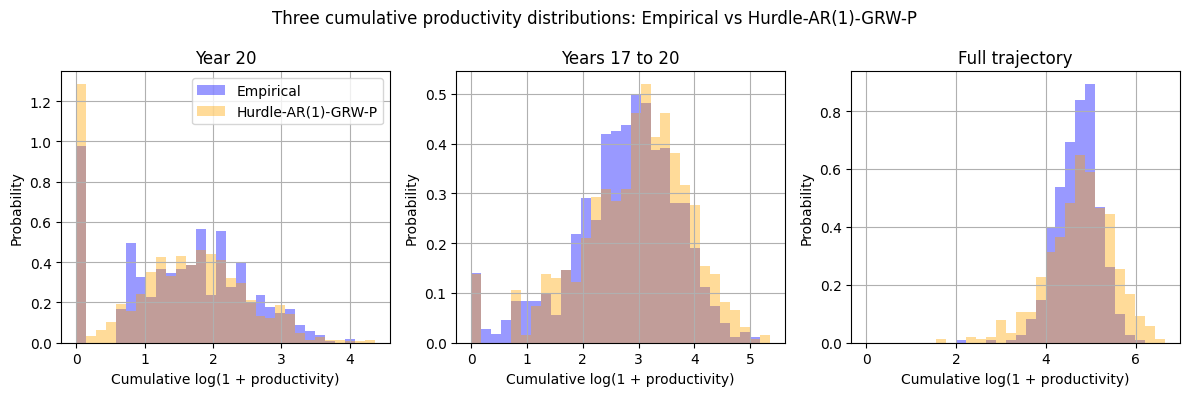

In [119]:
lastyear_sim = trajs_combined[20]
lastyear_emp = emp_panel_full[20]
hist_bins_lastyear = np.histogram_bin_edges((np.log1p(np.concat([[0],lastyear_sim, lastyear_emp]))),bins=30)

lastfour_sim = trajs_combined[-4:,:].sum(axis = 0)
lastfour_emp = emp_panel_full.iloc[:, -4:].sum(axis=1).to_numpy()
hist_bins_lastfour = np.histogram_bin_edges((np.log1p(np.concat([[0],lastfour_sim, lastfour_emp]))),bins=30)

cumsim = trajs_combined.sum(axis = 0)
cumemp = emp_panel_full.sum(axis=1).to_numpy()
hist_bins_cum = np.histogram_bin_edges((np.log1p(np.concat([[0],cumsim, cumemp]))),bins=30)


fig, ax = plt.subplots(1,3, figsize = (12,4))

ax[0].hist(np.log1p(lastyear_emp), bins = hist_bins_lastyear, alpha = 0.4, color = 'blue', label = 'Empirical', density = True)
ax[0].hist(np.log1p(lastyear_sim),bins=hist_bins_lastyear, alpha = 0.4, color = 'orange', label= f'{MODEL_NAME}', density=True)
ax[0].set_xlabel('Cumulative log(1 + productivity)')
ax[0].set_ylabel('Probability')
ax[0].set_title('Year 20')
ax[0].legend()
ax[0].grid(True)

ax[1].hist(np.log1p(lastfour_sim), bins = hist_bins_lastfour, alpha = 0.4, color = 'blue', label= f'{MODEL_NAME}', density = True)
ax[1].hist(np.log1p(lastfour_emp),bins=hist_bins_lastfour, alpha = 0.4, color = 'orange', label= 'Empirical', density=True)
ax[1].set_xlabel('Cumulative log(1 + productivity)')
ax[1].set_ylabel('Probability')
ax[1].set_title('Years 17 to 20')
ax[1].grid(True)

ax[2].hist(np.log1p(cumsim), bins = hist_bins_cum, alpha = 0.4, color = 'blue', label = f'{MODEL_NAME}', density = True)
ax[2].hist(np.log1p(cumemp), bins=hist_bins_cum, alpha = 0.4, color = 'orange', label='Empirical', density=True)
ax[2].set_xlabel('Cumulative log(1 + productivity)')
ax[2].set_ylabel('Probability')
ax[2].set_title('Full trajectory')
ax[2].grid(True)

plt.suptitle(f'Three cumulative productivity distributions: Empirical vs {MODEL_NAME}')
plt.tight_layout()
plt.show()

fig.savefig(FIGURES / f"{MODEL_TAG}_threecumdists.png",dpi=300, bbox_inches="tight")

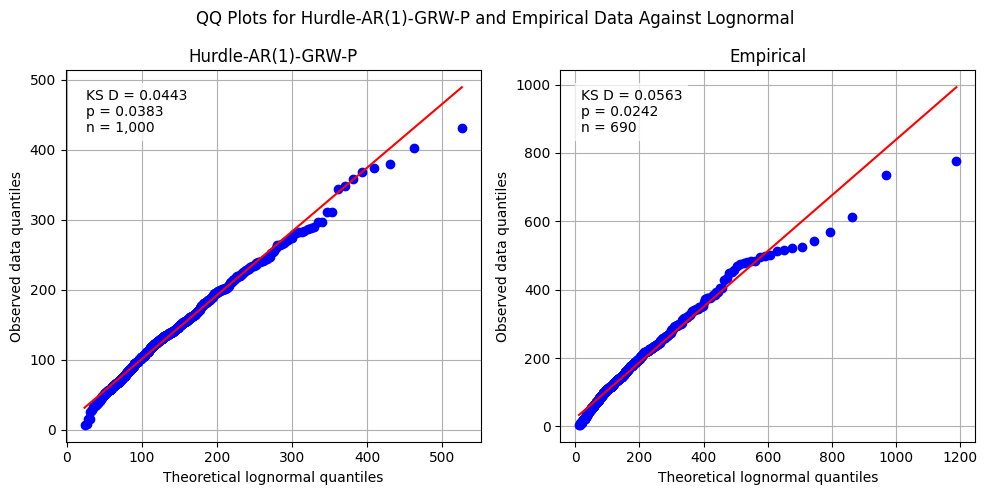

In [121]:
shape_sim, loc_sim, scale_sim = stats.lognorm.fit(np.asarray(cumsim + 0.49), floc=0)
shape_emp, loc_emp, scale_emp = stats.lognorm.fit(np.asarray(cumemp + 0.49), floc = 0)
ks_sim = stats.kstest(np.asarray(cumsim) + 0.49, stats.lognorm.cdf, args=(shape_sim, loc_sim, scale_sim))
ks_emp = stats.kstest(np.asarray(cumemp) + 0.49, stats.lognorm.cdf, args=(shape_emp, loc_emp, scale_emp))

# ks_sim_text = f"KS = {ks_sim.statistic:.4f}\np = {ks_sim.pvalue:.4g}"
# ks_emp_text = f"KS = {ks_emp.statistic:.4f}\np = {ks_emp.pvalue:.4g}"

ks_sim_text = f"KS D = {ks_sim.statistic:.4f}\np = {ks_sim.pvalue:.3g}\nn = {len(cumsim):,}"
ks_emp_text = f"KS D = {ks_emp.statistic:.4f}\np = {ks_emp.pvalue:.3g}\nn = {len(cumemp):,}"

fig, ax = plt.subplots(1,2, figsize=(10, 5))

stats.probplot(np.asarray(cumsim + 0.49),dist=stats.lognorm,sparams=(shape_sim, loc_sim, scale_sim),plot=ax[0])
stats.probplot(np.asarray(cumemp + 0.49),dist=stats.lognorm,sparams=(shape_emp, loc_emp, scale_emp),plot=ax[1])

ax[0].set_title(f"{MODEL_NAME}")
ax[0].set_xlabel("Theoretical lognormal quantiles")
ax[0].set_ylabel("Observed data quantiles")
ax[0].grid(True)
ax[0].text(0.05, 0.95,ks_sim_text,transform=ax[0].transAxes,va="top",ha="left",fontsize=10,bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))


ax[1].set_title('Empirical')
ax[1].set_xlabel("Theoretical lognormal quantiles")
ax[1].set_ylabel("Observed data quantiles")
ax[1].grid(True)
ax[1].text(0.05, 0.95,ks_emp_text,transform=ax[1].transAxes,va="top",ha="left",fontsize=10,bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

plt.suptitle(f'QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal')
plt.tight_layout()

fig.savefig(FIGURES / f"{MODEL_TAG}_qqlognorm.png",dpi=300, bbox_inches="tight")

plt.show()


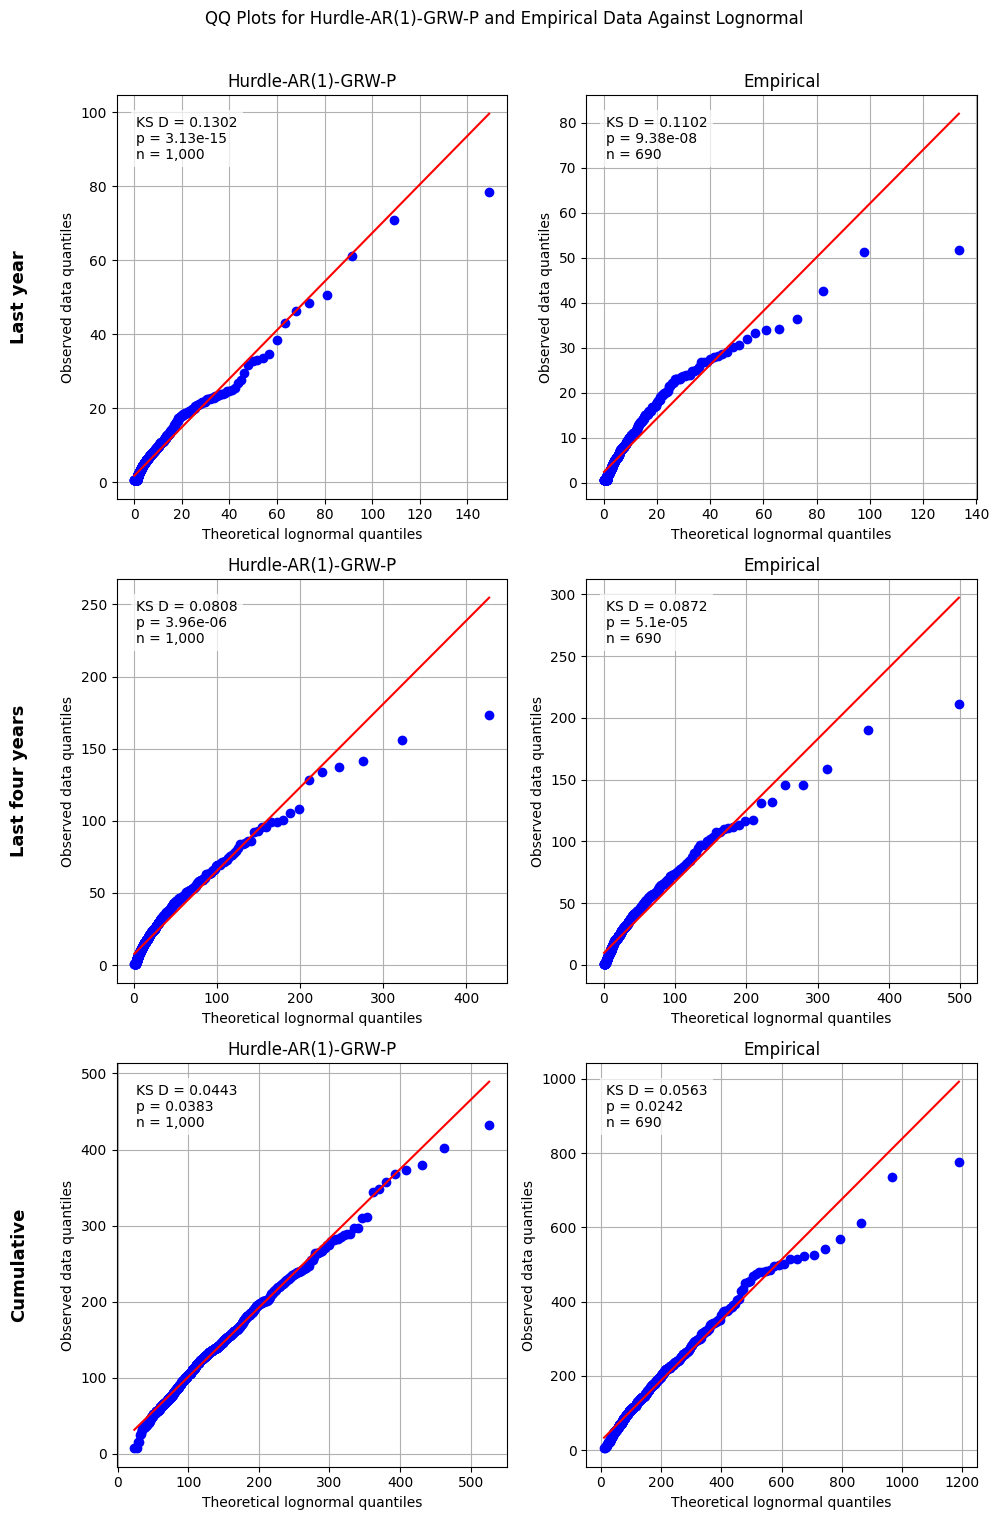

In [122]:

shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear = stats.lognorm.fit(np.asarray(lastyear_sim + 0.49), floc=0)
shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear = stats.lognorm.fit(np.asarray(lastyear_emp + 0.49), floc = 0)
ks_sim_lastyear = stats.kstest(np.asarray(lastyear_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear))
ks_emp_lastyear = stats.kstest(np.asarray(lastyear_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear))
ks_sim_text_lastyear = f"KS D = {ks_sim_lastyear.statistic:.4f}\np = {ks_sim_lastyear.pvalue:.3g}\nn = {len(lastyear_sim):,}"
ks_emp_text_lastyear = f"KS D = {ks_emp_lastyear.statistic:.4f}\np = {ks_emp_lastyear.pvalue:.3g}\nn = {len(lastyear_emp):,}"



#####


shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour = stats.lognorm.fit(np.asarray(lastfour_sim + 0.49), floc=0)
shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour = stats.lognorm.fit(np.asarray(lastfour_emp + 0.49), floc = 0)
ks_sim_lastfour = stats.kstest(np.asarray(lastfour_sim) + 0.49, stats.lognorm.cdf, args=(shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour))
ks_emp_lastfour = stats.kstest(np.asarray(lastfour_emp) + 0.49, stats.lognorm.cdf, args=(shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour))
ks_sim_text_lastfour = f"KS D = {ks_sim_lastfour.statistic:.4f}\np = {ks_sim_lastfour.pvalue:.3g}\nn = {len(lastfour_sim):,}"
ks_emp_text_lastfour = f"KS D = {ks_emp_lastfour.statistic:.4f}\np = {ks_emp_lastfour.pvalue:.3g}\nn = {len(lastfour_emp):,}"


#####


shape_sim_cum, loc_sim_cum, scale_sim_cum = stats.lognorm.fit(np.asarray(cumsim + 0.49), floc=0)
shape_emp_cum, loc_emp_cum, scale_emp_cum = stats.lognorm.fit(np.asarray(cumemp + 0.49), floc = 0)
ks_sim_cum = stats.kstest(np.asarray(cumsim) + 0.49, stats.lognorm.cdf, args=(shape_sim_cum, loc_sim_cum, scale_sim_cum))
ks_emp_cum = stats.kstest(np.asarray(cumemp) + 0.49, stats.lognorm.cdf, args=(shape_emp_cum, loc_emp_cum, scale_emp_cum))
ks_sim_text_cum = f"KS D = {ks_sim_cum.statistic:.4f}\np = {ks_sim_cum.pvalue:.3g}\nn = {len(cumsim):,}"
ks_emp_text_cum = f"KS D = {ks_emp_cum.statistic:.4f}\np = {ks_emp_cum.pvalue:.3g}\nn = {len(cumemp):,}"


#####


EPS = 0.49

fig, ax = plt.subplots(3,2, figsize=(10, 15))

qq_rows = [
    ("Last year", lastyear_sim, lastyear_emp,
     (shape_sim_lastyear, loc_sim_lastyear, scale_sim_lastyear),
     (shape_emp_lastyear, loc_emp_lastyear, scale_emp_lastyear),
     ks_sim_text_lastyear, ks_emp_text_lastyear),

    ("Last four years", lastfour_sim, lastfour_emp,
     (shape_sim_lastfour, loc_sim_lastfour, scale_sim_lastfour),
     (shape_emp_lastfour, loc_emp_lastfour, scale_emp_lastfour),
     ks_sim_text_lastfour, ks_emp_text_lastfour),

    ("Cumulative", cumsim, cumemp,
     (shape_sim_cum, loc_sim_cum, scale_sim_cum),
     (shape_emp_cum, loc_emp_cum, scale_emp_cum),
     ks_sim_text_cum, ks_emp_text_cum),
]

for r, (row_title, sim, emp, sim_params, emp_params, sim_text, emp_text) in enumerate(qq_rows):

    stats.probplot(np.asarray(sim, dtype=float) + EPS, dist=stats.lognorm, sparams=sim_params, plot=ax[r,0])
    stats.probplot(np.asarray(emp, dtype=float) + EPS, dist=stats.lognorm, sparams=emp_params, plot=ax[r,1])

    ax[r,0].set_title(f"{MODEL_NAME}")
    ax[r,1].set_title("Empirical")

    for c, ks_text in enumerate([sim_text, emp_text]):
        ax[r,c].set_xlabel("Theoretical lognormal quantiles")
        ax[r,c].set_ylabel("Observed data quantiles")
        ax[r,c].grid(True)
        ax[r,c].text(0.05, 0.95, ks_text, transform=ax[r,c].transAxes,
                     va="top", ha="left", fontsize=10,
                     bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

    ax[r,0].annotate(row_title, xy=(-0.25, 0.5), xycoords="axes fraction",
                     rotation=90, va="center", ha="center",
                     fontsize=13, fontweight="bold")

plt.suptitle(f"QQ Plots for {MODEL_NAME} and Empirical Data Against Lognormal", y=1.01)
plt.tight_layout()

fig.savefig(FIGURES / f"{MODEL_TAG}_qqlognorm_full.png", dpi=300, bbox_inches="tight")
plt.show()

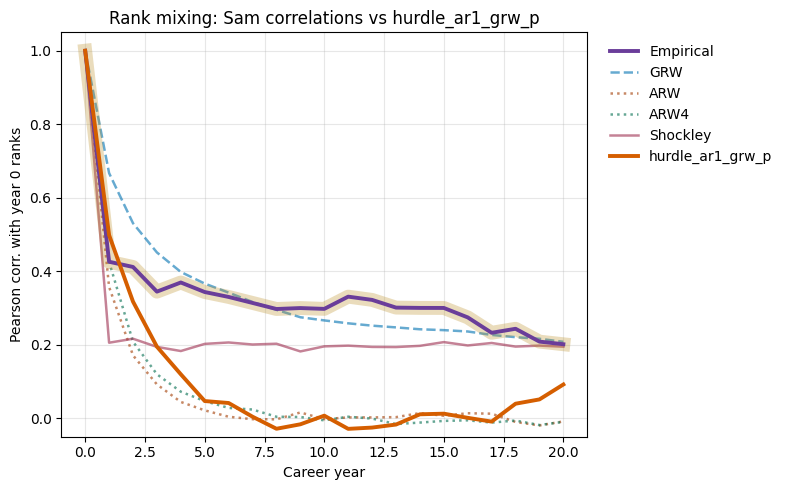

In [138]:
OUT = PROJ_ROOT / "data" / "trajectory_correlation_data"

sams_corr = pd.read_csv(OUT / "sams_correlations.csv")

TRJ = np.asarray(trajs_combined)
rank_0 = pd.Series(TRJ[0]).rank(method="average").to_numpy()

corr_traj = []
for t in range(Y + 1):
    rank_t = pd.Series(TRJ[t]).rank(method="average").to_numpy()
    corr_traj.append(np.corrcoef(rank_0, rank_t)[0, 1])

corr_traj = pd.DataFrame({
    "CareerAge": np.arange(Y + 1),
    MODEL_TAG: corr_traj,})

palette = ["#0072B2", "#A23B00", "#006D4E", "#6A3D9A", "#9E2F50", "#D55E00"]

sams_corr.insert(0, "CareerAge", np.arange(len(sams_corr)))

corr_compare = sams_corr.merge(corr_traj, on="CareerAge", how="left")
corr_compare.to_csv(OUT / f"{MODEL_TAG}_corrCompare.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(corr_compare["CareerAge"], corr_compare["CS_empirical"], color=palette[3], linewidth=2.8, label="Empirical", zorder=6)
ax.plot(corr_compare["CareerAge"], corr_compare["CS_empirical"], color='#BA8E23', alpha = 0.3, linewidth=10, zorder=4)

ax.plot(corr_compare["CareerAge"], corr_compare["GRW"], color=palette[0], linestyle="dashed", linewidth=1.8, alpha=0.6, label="GRW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW"], color=palette[1], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW")
ax.plot(corr_compare["CareerAge"], corr_compare["ARW4"], color=palette[2], linestyle="dotted", linewidth=1.8, alpha=0.6, label="ARW4")
ax.plot(corr_compare["CareerAge"], corr_compare["Shockley"], color=palette[4], linewidth=1.8, alpha=0.6, label="Shockley")

ax.plot(corr_compare["CareerAge"], corr_compare[MODEL_TAG], color=palette[5], linewidth=2.8, label=MODEL_TAG, zorder=7)

ax.set_title(f"Rank mixing: Sam correlations vs {MODEL_TAG}")
ax.set_xlabel("Career year")
ax.set_ylabel("Pearson corr. with year 0 ranks")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(OUT / f"{MODEL_TAG}_corrCompare.png", dpi=300, bbox_inches="tight")
plt.show()
